In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [7]:
week5_results = {
    "f1": ([0.812650, 0.143347], -1.0629331180647184e-161),
    "f2": ([0.678746, 0.850809], 0.6824523528240423),
    "f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209),
    "f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175),
    "f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044),
    "f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992),
    "f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274),
    "f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954),
}

In [8]:
week6_results = {
    "f1": ([0.079265, 0.909848], 2.6078826238924974e-248),
    "f2": ([0.653993, 0.981188], 0.3798198130144502),
    "f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577),
    "f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453),
    "f5": ([0.000000, 0.856410, 1.000000, 0.433460], 849.8436606636637),
    "f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937),
    "f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691),
    "f8": ([0.924338, 0.001471, 0.948665, 0.928797, 0.142329, 0.071686, 0.034416, 0.347751], 5.5407934131584),
}

In [9]:
week7_results = {
    "f1": ([0.525569, 0.987823], 2.2360328065267756e-98),
    "f2": ([0.000128, 0.346419], 0.005940965665866974),
    "f3": ([0.110343, 0.915465, 0.655916], -0.12413097550625916),
    "f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117),
    "f5": ([0.998891, 0.926298, 0.985415, 0.964459], 6575.295982756673),
    "f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772),
    "f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517),
    "f8": ([0.088856, 0.892449, 0.024530, 0.962260, 0.982699, 0.389537, 0.966989, 0.307254], 7.5413772236639005),
}

In [10]:
week8_results = {
    "f1": ([0.994902, 0.994221], 3.029971271826444e-187),
    "f2": ([0.920304, 0.040061], -0.03174629008935288),
    "f3": ([0.394618, 0.003779, 0.001514], -0.18116078744677863),
    "f4": ([0.413226, 0.408926, 0.383757, 0.471737], -0.9393775297880427),
    "f5": ([0.714539, 0.952855, 0.995586, 0.996033], 4660.244115920329),
    "f6": ([0.987971, 0.066922, 0.908036, 0.000615, 0.964637], -2.7568441153569343),
    "f7": ([0.186891, 0.934228, 0.522974, 0.187825, 0.066947, 0.841778], 0.13054782987236474),
    "f8": ([0.041050, 0.781948, 0.001813, 0.992673, 0.545189, 0.662834, 0.042235, 0.825023], 8.7204756545406),
}

In [11]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (18, 3)
f2 updated shape: (18, 3)
f3 updated shape: (23, 4)
f4 updated shape: (38, 5)
f5 updated shape: (28, 5)
f6 updated shape: (28, 6)
f7 updated shape: (38, 7)
f8 updated shape: (47, 9)


In [12]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  

In [13]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,18.0,0.608702,0.267801,0.079265,4.392201e-01,7.065721e-01,7.988507e-01,9.949020e-01
X2,18.0,0.566292,0.329731,0.002800,2.896667e-01,6.738977e-01,8.365329e-01,9.942210e-01
y1,18.0,-0.000200,0.000850,-0.003606,2.267277e-223,1.803386e-81,7.903833e-47,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,18.0,0.590885,0.266288,0.000128,0.442286,0.659896,0.724631,0.999500
X2,18.0,0.491670,0.352518,0.001800,0.193822,0.456453,0.776964,0.999446
y1,18.0,0.236495,0.269069,-0.079755,-0.008908,0.229792,0.482924,0.682452



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,28.0,0.546442,0.281068,0.021735,0.337459,0.578225,0.760851,0.987971
X2,28.0,0.446532,0.311489,0.001300,0.229100,0.343817,0.759499,0.931871
X3,28.0,0.532488,0.314045,0.016523,0.344281,0.516000,0.817541,0.978806
X4,28.0,0.579185,0.316034,0.000615,0.329066,0.679768,0.821462,1.000000
X5,28.0,0.403350,0.306608,0.000000,0.111981,0.357652,0.628985,0.964637
y1,28.0,-1.407293,0.569402,-2.756844,-1.713639,-1.332899,-0.909127,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,38.0,0.437001,0.326613,0.000000,0.102741,0.447225,0.755261,0.942451
X2,38.0,0.422396,0.265912,0.011813,0.217308,0.387701,0.598333,0.949047
X3,38.0,0.412619,0.301487,0.003635,0.126176,0.364957,0.654407,0.924571
X4,38.0,0.459234,0.300009,0.073659,0.212702,0.372232,0.750193,0.961017
X5,38.0,0.451616,0.289150,0.014944,0.208411,0.417030,0.689444,0.998655
X6,38.0,0.527956,0.278479,0.051100,0.344457,0.626393,0.730030,0.980800
y1,38.0,0.361441,0.534138,0.002701,0.022643,0.097959,0.511876,2.448291



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,47.0,0.501280,0.315401,0.009077,0.191704,0.481245,0.785353,0.985945
X2,47.0,0.470675,0.319848,0.001471,0.191912,0.523642,0.766547,0.973980
X3,47.0,0.474663,0.303894,0.001813,0.248229,0.416796,0.728788,0.998885
X4,47.0,0.444949,0.285791,0.009043,0.189197,0.452656,0.672913,0.992673
X5,47.0,0.490138,0.283205,0.009649,0.243904,0.480619,0.732423,0.986902
X6,47.0,0.457162,0.266279,0.022113,0.248903,0.409325,0.676505,0.990244
X7,47.0,0.542995,0.284613,0.034416,0.265368,0.591030,0.764076,0.992914
X8,47.0,0.511250,0.268343,0.041956,0.310468,0.525348,0.722286,0.988755
y1,47.0,7.925621,1.089234,5.540793,7.305383,7.957875,8.663296,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,-0.003800,-0.038592
X2,-0.003800,1.000000,-0.087219
y1,-0.038592,-0.087219,1.000000


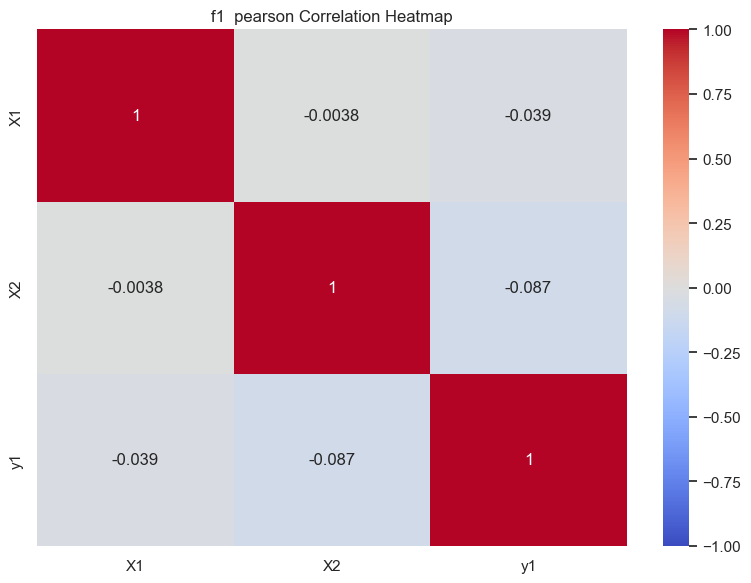


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.094737,0.361241
X2,0.094737,1.000000,0.366448
y1,0.361241,0.366448,1.000000


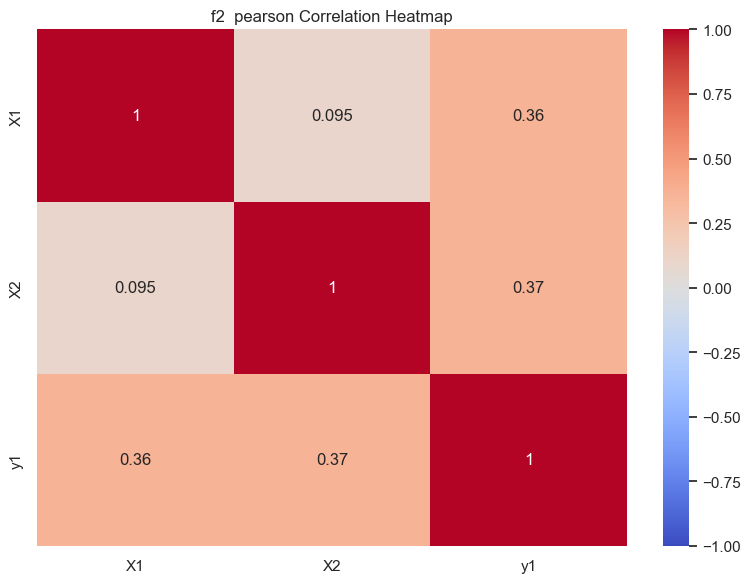


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.137591,0.026568,0.151494
X2,0.137591,1.000000,-0.042515,0.313180
X3,0.026568,-0.042515,1.000000,-0.313532
y1,0.151494,0.313180,-0.313532,1.000000


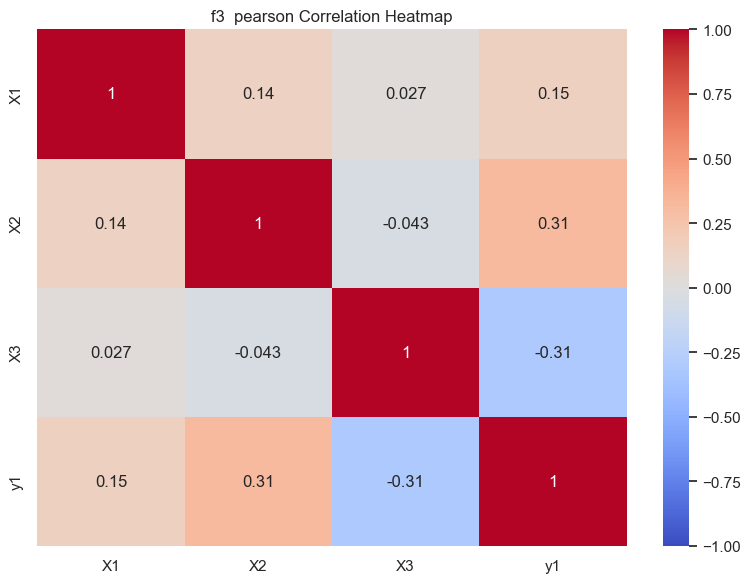


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.256025,0.271215,0.198285,-0.512155
X2,0.256025,1.000000,-0.061432,0.190523,-0.404573
X3,0.271215,-0.061432,1.000000,-0.142840,-0.163632
X4,0.198285,0.190523,-0.142840,1.000000,-0.414686
y1,-0.512155,-0.404573,-0.163632,-0.414686,1.000000


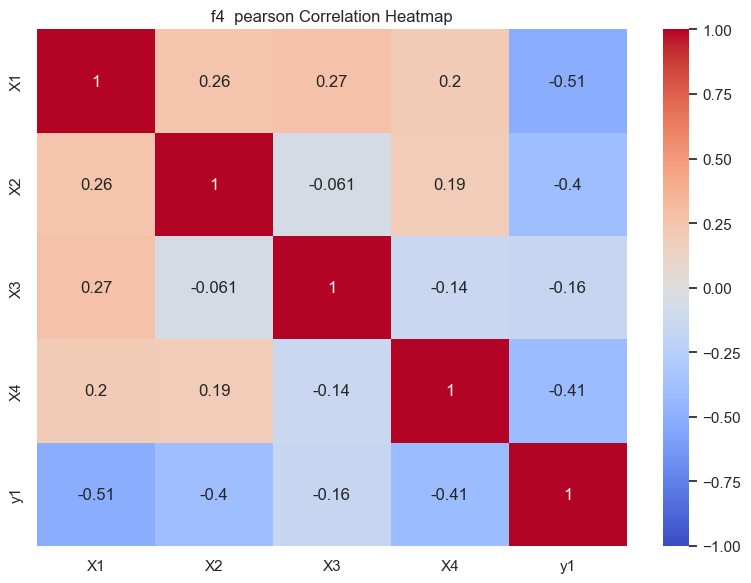


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.019675,0.061725,0.329871,0.478759
X2,0.019675,1.000000,0.339540,0.232625,0.522099
X3,0.061725,0.339540,1.000000,-0.006062,0.565685
X4,0.329871,0.232625,-0.006062,1.000000,0.482486
y1,0.478759,0.522099,0.565685,0.482486,1.000000


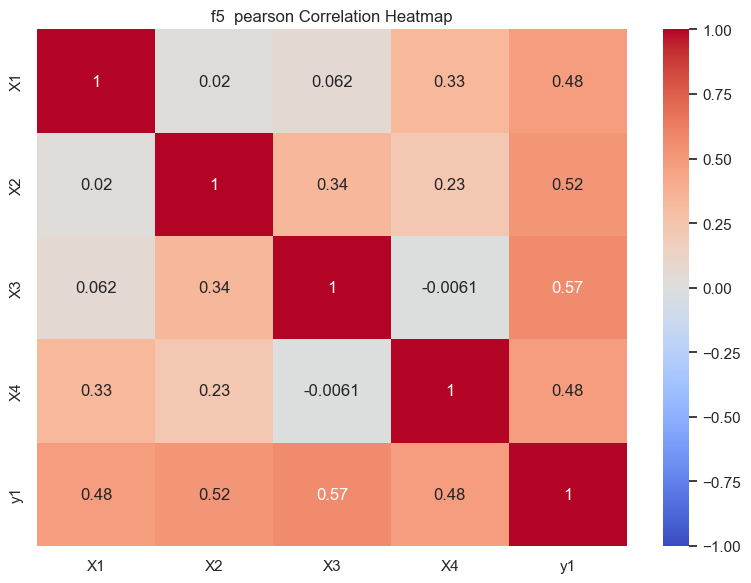


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.173815,-0.047652,-0.059869,-0.240801,-0.056807
X2,-0.173815,1.000000,-0.022517,-0.156395,0.116032,-0.230971
X3,-0.047652,-0.022517,1.000000,0.197055,-0.013293,0.120184
X4,-0.059869,-0.156395,0.197055,1.000000,-0.360544,0.622668
X5,-0.240801,0.116032,-0.013293,-0.360544,1.000000,-0.721086
y1,-0.056807,-0.230971,0.120184,0.622668,-0.721086,1.000000


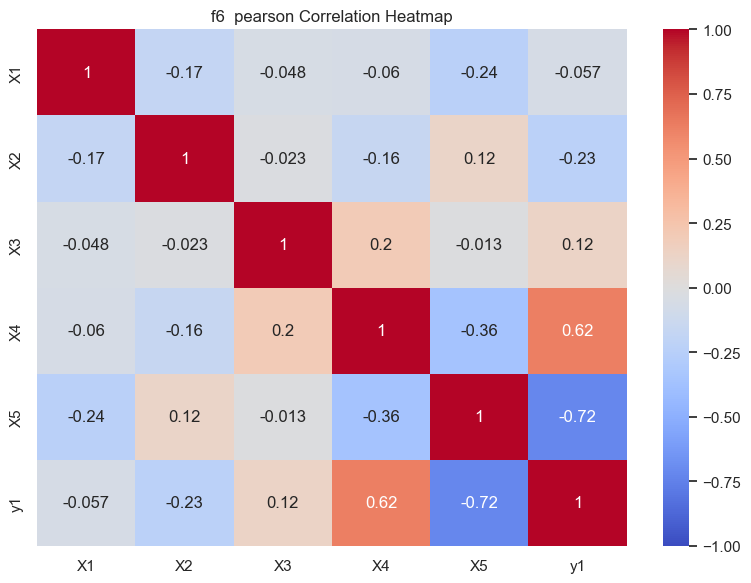


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.026689,-0.144798,0.032633,0.057454,-0.514326,-0.477589
X2,-0.026689,1.000000,0.113095,0.074438,0.221257,0.220310,-0.096353
X3,-0.144798,0.113095,1.000000,0.142659,-0.253218,0.100167,0.140258
X4,0.032633,0.074438,0.142659,1.000000,0.101869,-0.052866,-0.229820
X5,0.057454,0.221257,-0.253218,0.101869,1.000000,0.000228,-0.214040
X6,-0.514326,0.220310,0.100167,-0.052866,0.000228,1.000000,0.331901
y1,-0.477589,-0.096353,0.140258,-0.229820,-0.214040,0.331901,1.000000


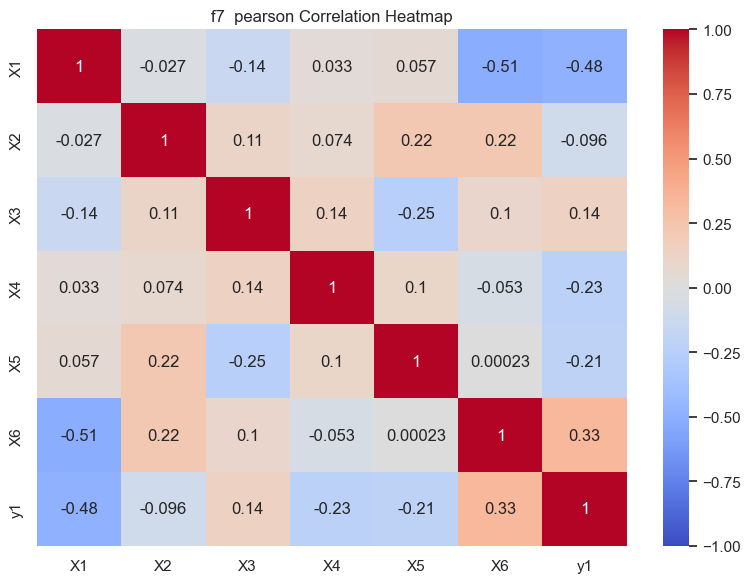


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.041214,0.232551,0.063708,0.099974,0.083303,0.144766,0.066771,-0.639072
X2,0.041214,1.000000,-0.006325,-0.075493,0.123909,0.074299,-0.004279,-0.228992,-0.179110
X3,0.232551,-0.006325,1.000000,0.031536,-0.194313,-0.229531,-0.086402,-0.051533,-0.674391
X4,0.063708,-0.075493,0.031536,1.000000,-0.037233,-0.121467,-0.086448,0.303331,-0.232349
X5,0.099974,0.123909,-0.194313,-0.037233,1.000000,0.097585,0.185855,0.071989,0.013547
X6,0.083303,0.074299,-0.229531,-0.121467,0.097585,1.000000,0.016930,0.093204,0.127833
X7,0.144766,-0.004279,-0.086402,-0.086448,0.185855,0.016930,1.000000,-0.182759,-0.297090
X8,0.066771,-0.228992,-0.051533,0.303331,0.071989,0.093204,-0.182759,1.000000,0.128456
y1,-0.639072,-0.179110,-0.674391,-0.232349,0.013547,0.127833,-0.297090,0.128456,1.000000


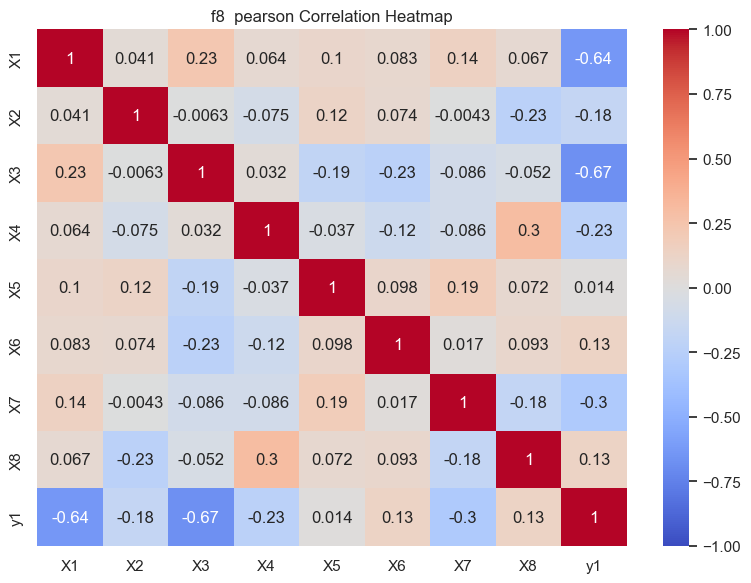

In [14]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.151703,0.199174
X2,-0.151703,1.000000,0.353973
y1,0.199174,0.353973,1.000000


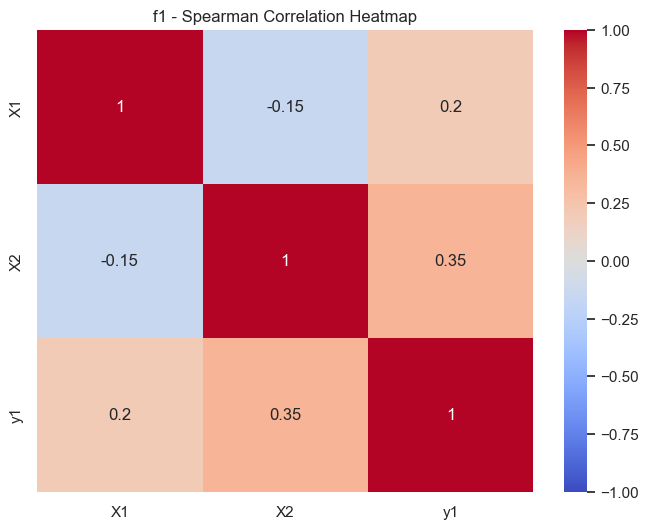


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.046440,0.271414
X2,-0.046440,1.000000,0.329205
y1,0.271414,0.329205,1.000000


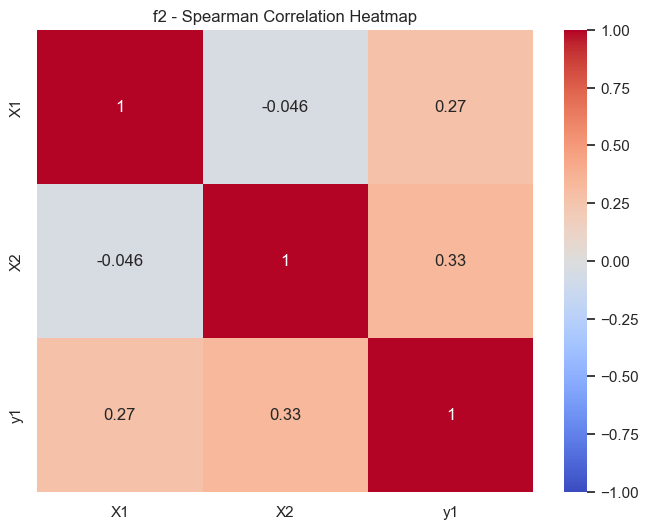


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.148221,-0.078063,0.135375
X2,0.148221,1.000000,-0.026680,0.342885
X3,-0.078063,-0.026680,1.000000,-0.102767
y1,0.135375,0.342885,-0.102767,1.000000


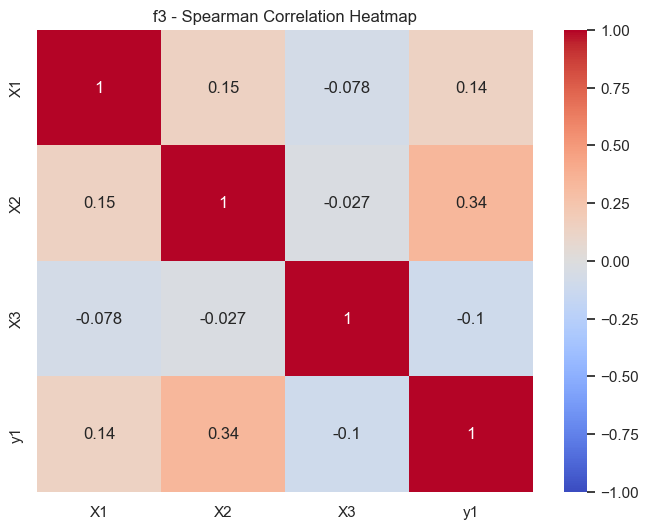


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.264471,0.257030,0.196411,-0.483094
X2,0.264471,1.000000,-0.007112,0.167961,-0.425320
X3,0.257030,-0.007112,1.000000,-0.186782,-0.160959
X4,0.196411,0.167961,-0.186782,1.000000,-0.358354
y1,-0.483094,-0.425320,-0.160959,-0.358354,1.000000


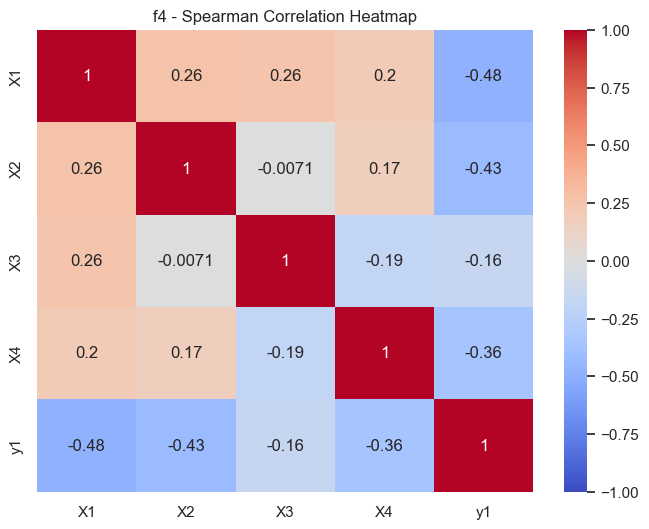


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.018062,0.054195,0.313629,0.126984
X2,-0.018062,1.000000,0.456001,0.238095,0.568144
X3,0.054195,0.456001,1.000000,0.021623,0.657178
X4,0.313629,0.238095,0.021623,1.000000,0.468528
y1,0.126984,0.568144,0.657178,0.468528,1.000000


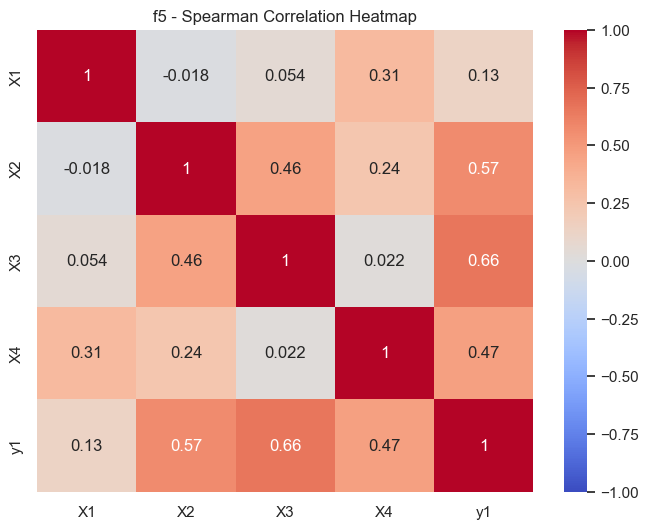


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.127840,-0.016151,-0.043794,-0.244423,-0.075818
X2,-0.127840,1.000000,-0.114153,-0.152183,0.043520,-0.192966
X3,-0.016151,-0.114153,1.000000,0.263857,-0.028740,0.140961
X4,-0.043794,-0.152183,0.263857,1.000000,-0.394636,0.587849
X5,-0.244423,0.043520,-0.028740,-0.394636,1.000000,-0.695129
y1,-0.075818,-0.192966,0.140961,0.587849,-0.695129,1.000000


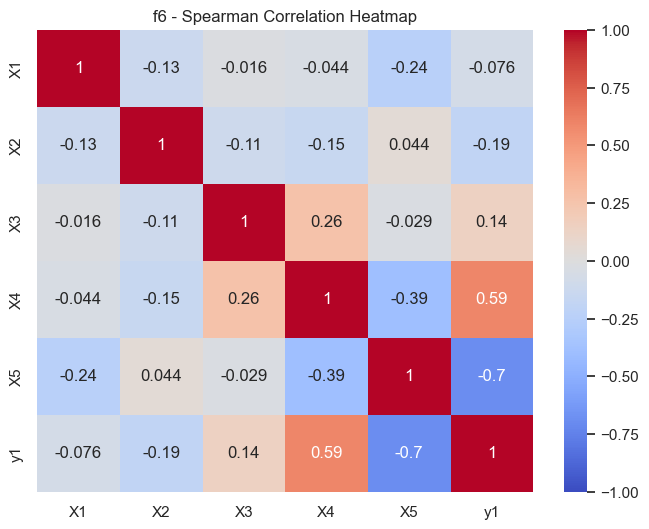


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.051537,-0.126600,0.041471,0.027465,-0.489003,-0.517672
X2,-0.051537,1.000000,0.088084,0.147609,0.257030,0.199256,-0.125725
X3,-0.126600,0.088084,1.000000,0.101215,-0.241711,0.140387,0.263596
X4,0.041471,0.147609,0.101215,1.000000,0.111500,-0.009301,-0.185469
X5,0.027465,0.257030,-0.241711,0.111500,1.000000,-0.050224,-0.396871
X6,-0.489003,0.199256,0.140387,-0.009301,-0.050224,1.000000,0.345005
y1,-0.517672,-0.125725,0.263596,-0.185469,-0.396871,0.345005,1.000000


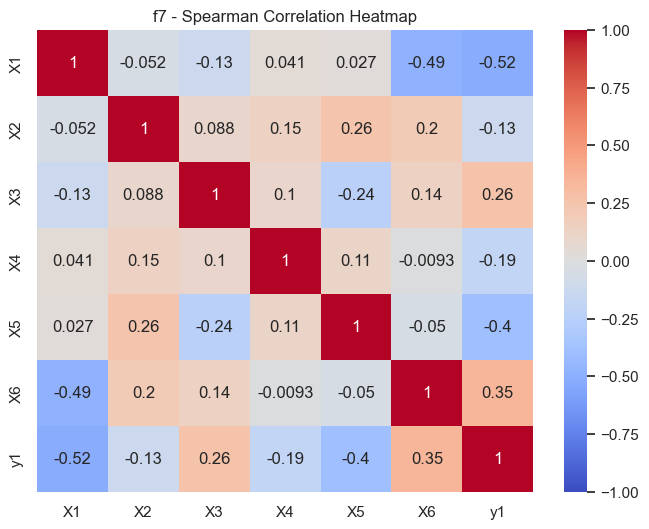


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.039432,0.224561,0.070539,0.107080,0.072967,0.123844,0.053540,-0.636448
X2,0.039432,1.000000,0.000867,-0.101012,0.111651,0.072911,0.009771,-0.226482,-0.187968
X3,0.224561,0.000867,1.000000,0.069093,-0.192940,-0.213177,-0.067993,-0.093839,-0.638298
X4,0.070539,-0.101012,0.069093,1.000000,-0.065857,-0.143568,-0.059611,0.285921,-0.219190
X5,0.107080,0.111651,-0.192940,-0.065857,1.000000,0.134894,0.190396,0.050477,0.032089
X6,0.072967,0.072911,-0.213177,-0.143568,0.134894,1.000000,0.046660,0.126915,0.075338
X7,0.123844,0.009771,-0.067993,-0.059611,0.190396,0.046660,1.000000,-0.176751,-0.326434
X8,0.053540,-0.226482,-0.093839,0.285921,0.050477,0.126915,-0.176751,1.000000,0.123905
y1,-0.636448,-0.187968,-0.638298,-0.219190,0.032089,0.075338,-0.326434,0.123905,1.000000


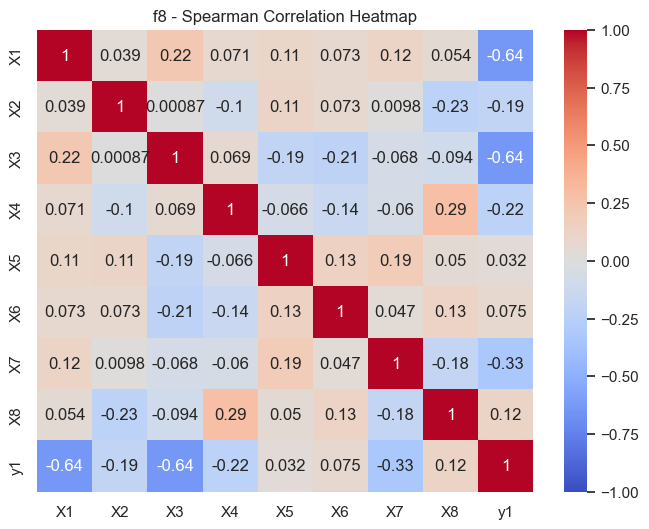

In [15]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.150327,0.124183
X2,-0.150327,1.000000,0.228758
y1,0.124183,0.228758,1.000000


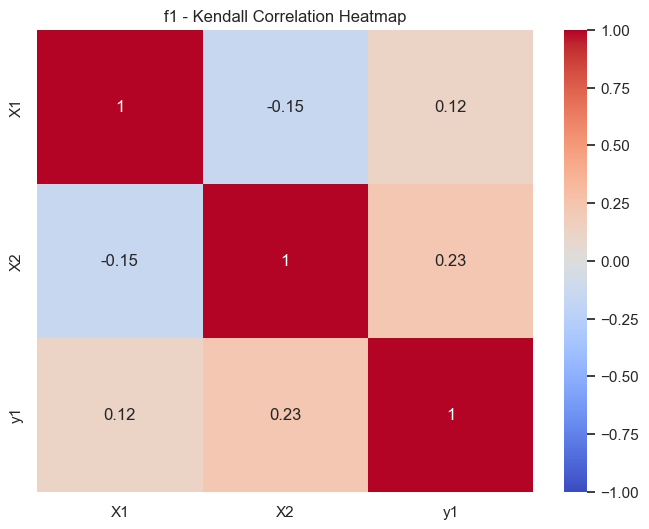


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.045752,0.202614
X2,-0.045752,1.000000,0.254902
y1,0.202614,0.254902,1.000000


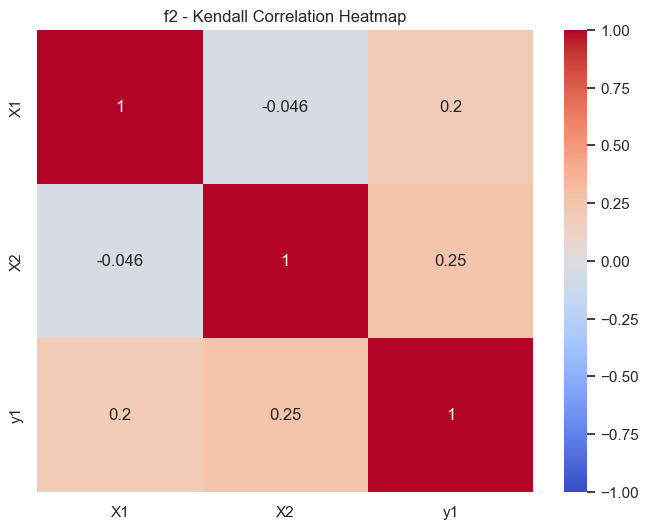


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.114625,-0.059289,0.114625
X2,0.114625,1.000000,-0.027668,0.256917
X3,-0.059289,-0.027668,1.000000,-0.043478
y1,0.114625,0.256917,-0.043478,1.000000


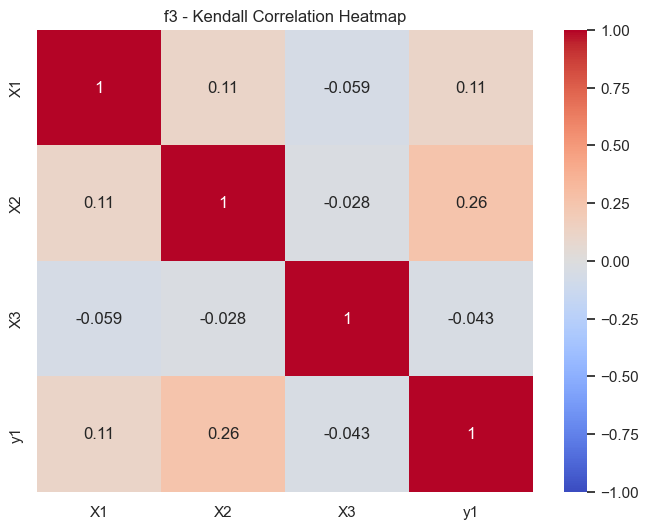


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.172119,0.197724,0.135135,-0.331437
X2,0.172119,1.000000,0.018492,0.120910,-0.294452
X3,0.197724,0.018492,1.000000,-0.143670,-0.160740
X4,0.135135,0.120910,-0.143670,1.000000,-0.251778
y1,-0.331437,-0.294452,-0.160740,-0.251778,1.000000


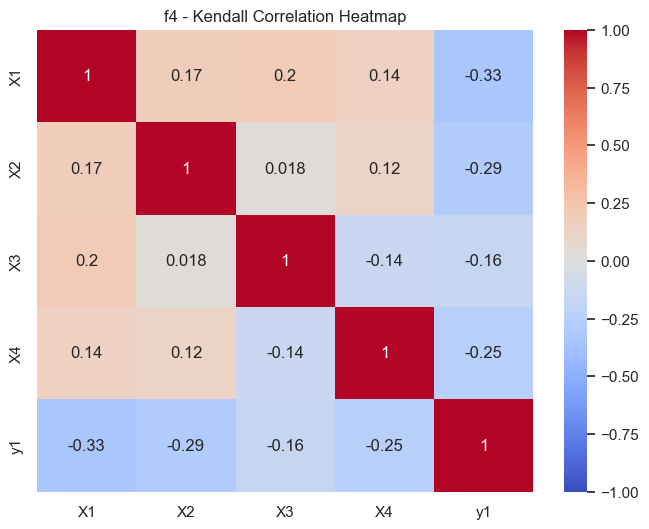


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.021164,0.023841,0.232804,0.052910
X2,-0.021164,1.000000,0.294040,0.153439,0.375661
X3,0.023841,0.294040,1.000000,-0.013245,0.484769
X4,0.232804,0.153439,-0.013245,1.000000,0.322751
y1,0.052910,0.375661,0.484769,0.322751,1.000000


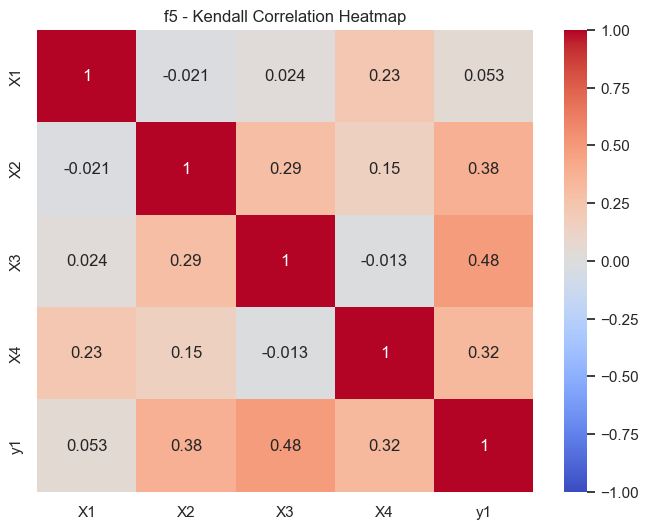


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.108753,-0.007958,-0.013245,-0.198676,-0.050331
X2,-0.108753,1.000000,-0.076923,-0.103311,0.018543,-0.150994
X3,-0.007958,-0.076923,1.000000,0.188080,-0.007947,0.108609
X4,-0.013245,-0.103311,0.188080,1.000000,-0.322751,0.444444
X5,-0.198676,0.018543,-0.007947,-0.322751,1.000000,-0.507937
y1,-0.050331,-0.150994,0.108609,0.444444,-0.507937,1.000000


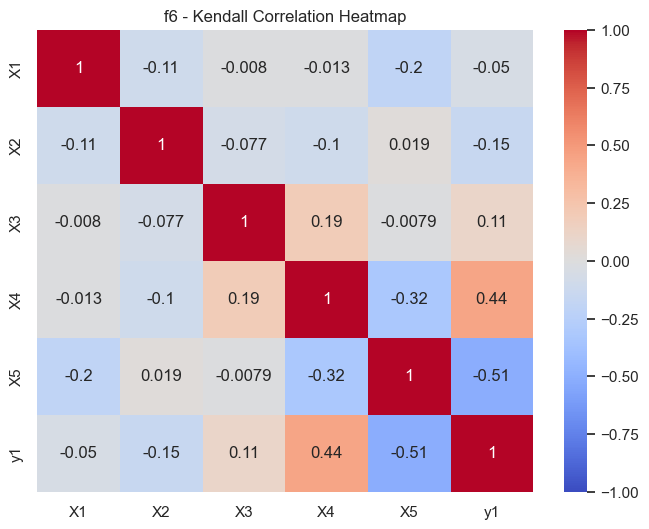


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.012802,-0.081081,0.021337,0.004267,-0.337127,-0.394026
X2,-0.012802,1.000000,0.061166,0.095306,0.180654,0.112376,-0.092461
X3,-0.081081,0.061166,1.000000,0.044097,-0.155050,0.106686,0.169275
X4,0.021337,0.095306,0.044097,1.000000,0.078236,-0.018492,-0.137980
X5,0.004267,0.180654,-0.155050,0.078236,1.000000,-0.029872,-0.251778
X6,-0.337127,0.112376,0.106686,-0.018492,-0.029872,1.000000,0.220484
y1,-0.394026,-0.092461,0.169275,-0.137980,-0.251778,0.220484,1.000000


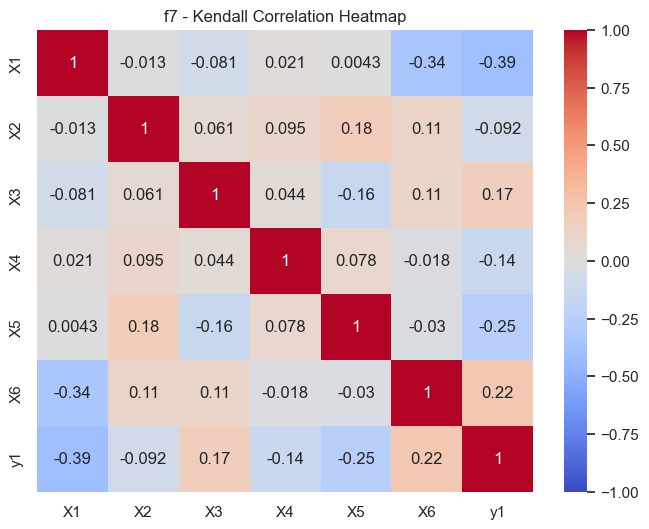


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.037020,0.134135,0.042573,0.066636,0.029616,0.073080,0.027765,-0.450509
X2,0.037020,1.000000,-0.005553,-0.079630,0.088889,0.025926,-0.003702,-0.135185,-0.112911
X3,0.134135,-0.005553,1.000000,0.033318,-0.131421,-0.153633,-0.045328,-0.070338,-0.465310
X4,0.042573,-0.079630,0.033318,1.000000,-0.038889,-0.072222,-0.035169,0.203704,-0.144378
X5,0.066636,0.088889,-0.131421,-0.038889,1.000000,0.100000,0.133272,0.038889,0.031467
X6,0.029616,0.025926,-0.153633,-0.072222,0.100000,1.000000,0.040722,0.079630,0.038871
X7,0.073080,-0.003702,-0.045328,-0.035169,0.133272,0.040722,1.000000,-0.116613,-0.252544
X8,0.027765,-0.135185,-0.070338,0.203704,0.038889,0.079630,-0.116613,1.000000,0.085146
y1,-0.450509,-0.112911,-0.465310,-0.144378,0.031467,0.038871,-0.252544,0.085146,1.000000


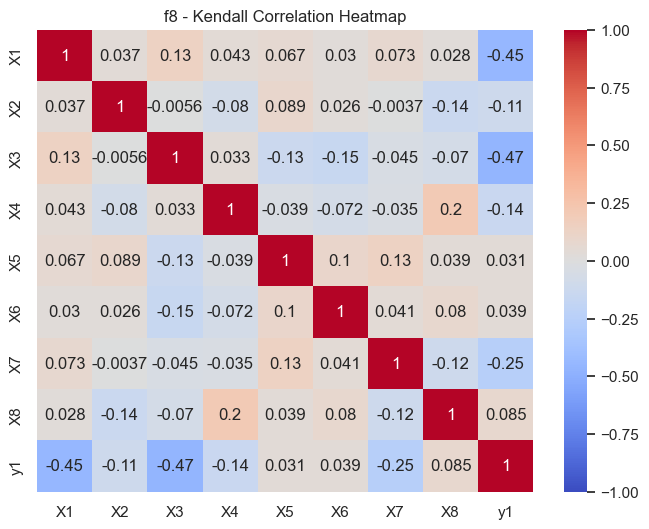

In [16]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [17]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0
1,X2,0



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.320196
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.357666
3,X4,0.122803
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.144301
4,X5,0.137339
0,X1,0.126348
1,X2,0.015238
2,X3,0.002888
3,X4,0.001716



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.322772
0,X1,0.284140
6,X7,0.114263
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Partial Correlation

In [18]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  18 -0.039073  [-0.51, 0.45]  0.881644
          n         r          CI95%     p-val
pearson  18 -0.087431  [-0.55, 0.41]  0.738628

f2 — Partial Correlation
          n         r          CI95%     p-val
pearson  18  0.352522  [-0.15, 0.71]  0.165195
          n         r          CI95%   p-val
pearson  18  0.357894  [-0.15, 0.72]  0.1584

f3 — Partial Correlation
          n        r          CI95%     p-val
pearson  23  0.13248  [-0.32, 0.53]  0.567012
          n         r          CI95%     p-val
pearson  23  0.299817  [-0.15, 0.65]  0.186693
          n         r          CI95%    p-val
pearson  23 -0.322502  [-0.66, 0.13]  0.15392

f4 — Partial Correlation
          n         r           CI95%     p-val
pearson  38 -0.384793  [-0.64, -0.06]  0.022461
          n        r          CI95%     p-val
pearson  38 -0.31668  [-0.59, 0.02]  0.063812
          n         r          CI95%     p-val
pearson  38

#### Feature vs Output Plots 


Feature vs Output Plots for f1
X shape for f1: (18, 2)
y shape for f1: (18,)


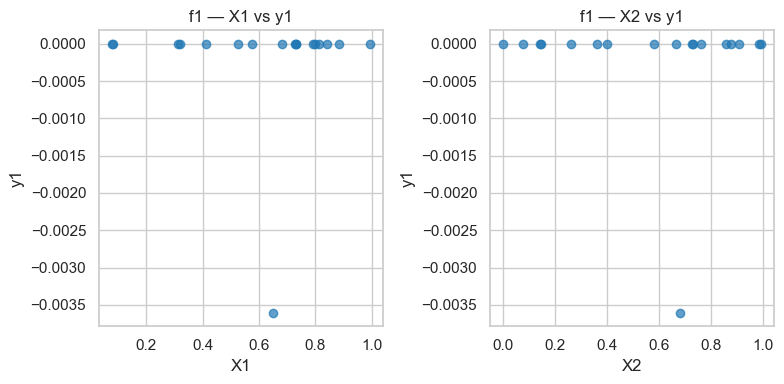


Feature vs Output Plots for f2
X shape for f2: (18, 2)
y shape for f2: (18,)


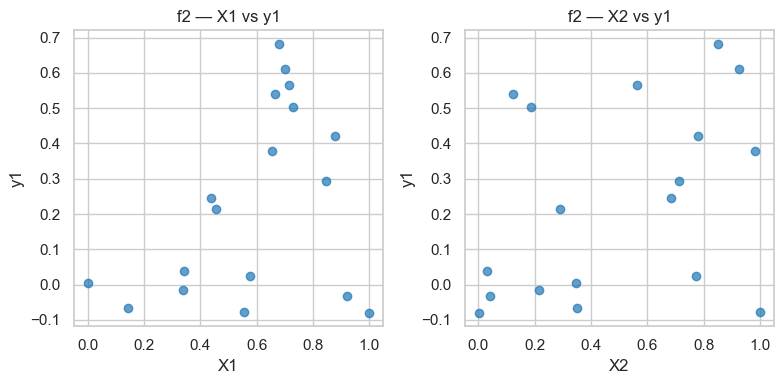


Feature vs Output Plots for f3
X shape for f3: (23, 3)
y shape for f3: (23,)


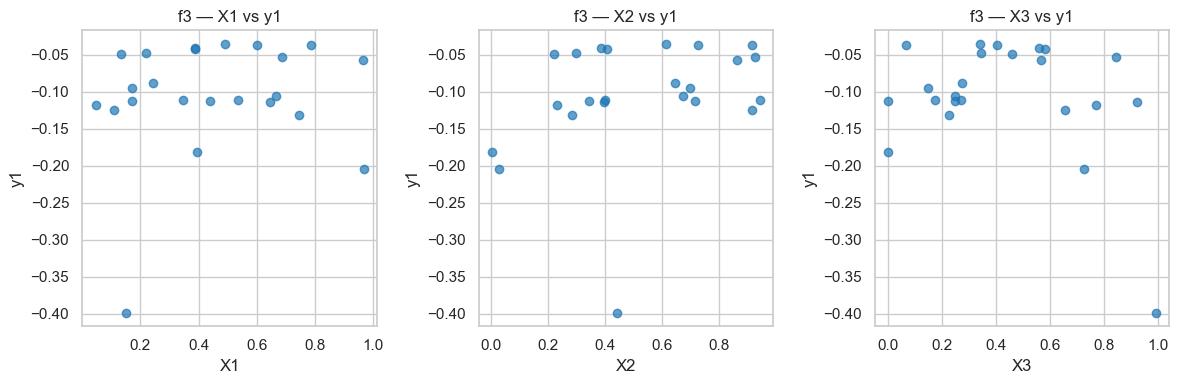


Feature vs Output Plots for f4
X shape for f4: (38, 4)
y shape for f4: (38,)


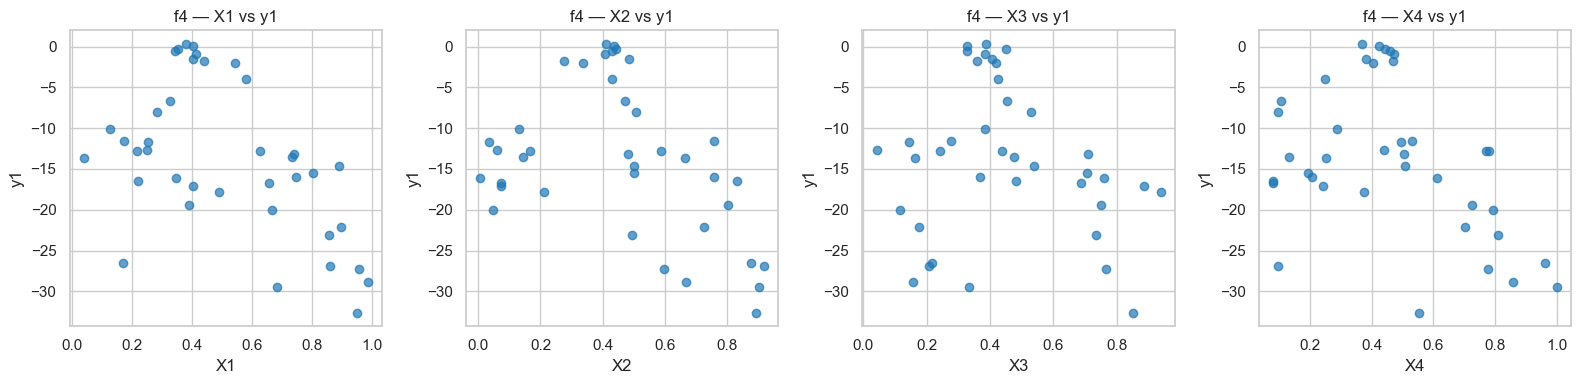


Feature vs Output Plots for f5
X shape for f5: (28, 4)
y shape for f5: (28,)


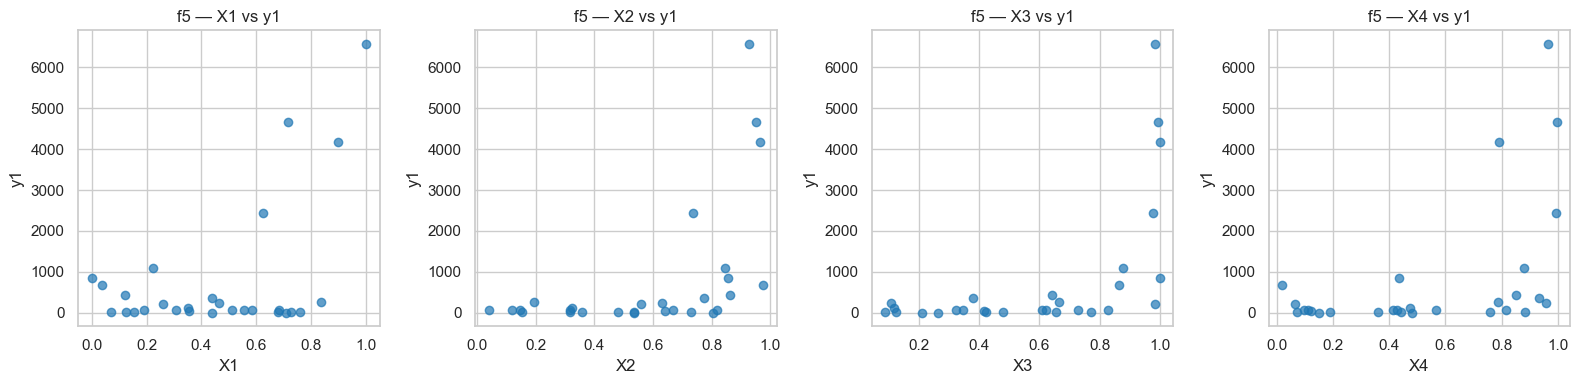


Feature vs Output Plots for f6
X shape for f6: (28, 5)
y shape for f6: (28,)


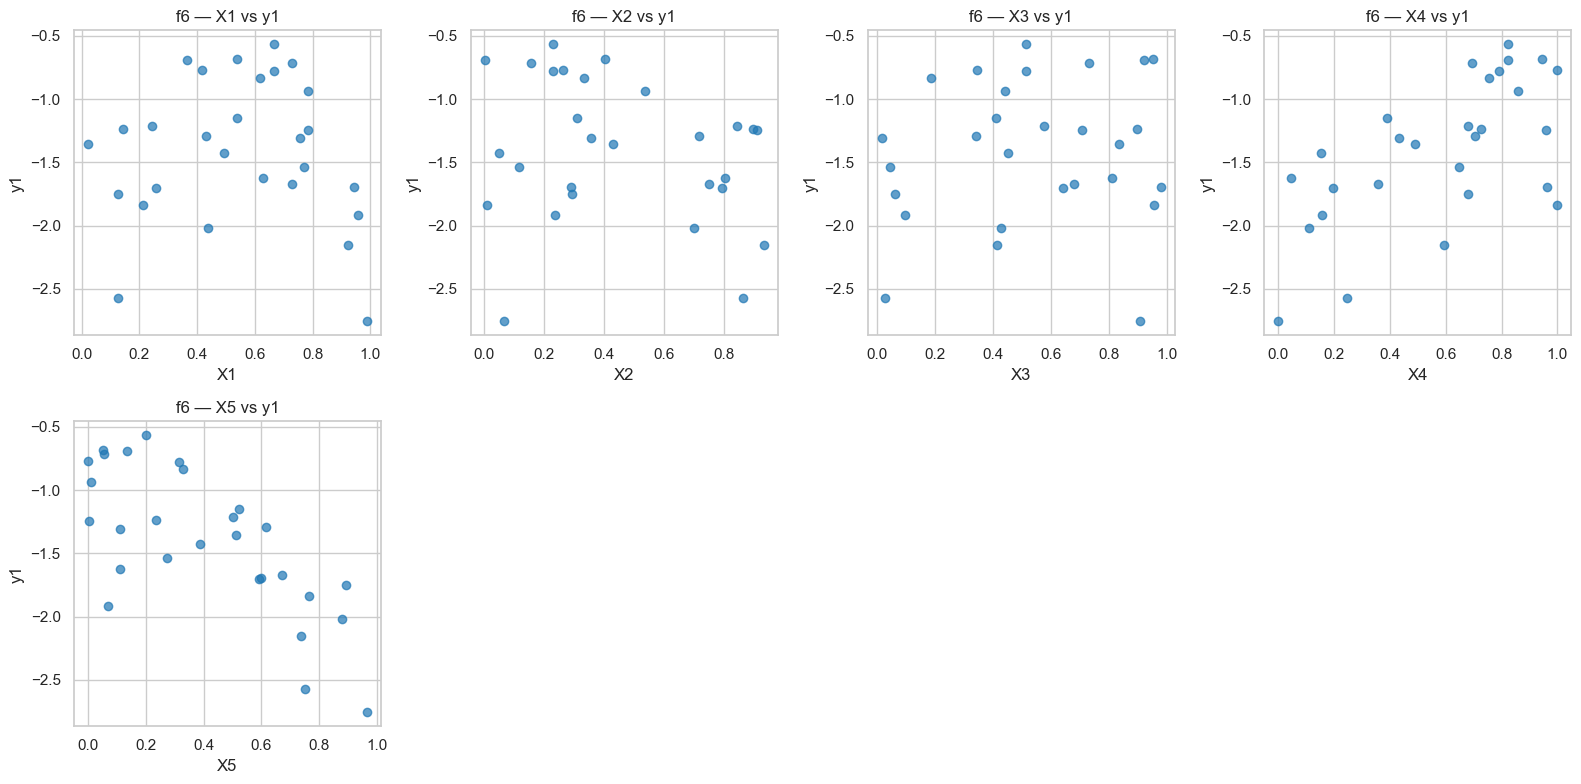


Feature vs Output Plots for f7
X shape for f7: (38, 6)
y shape for f7: (38,)


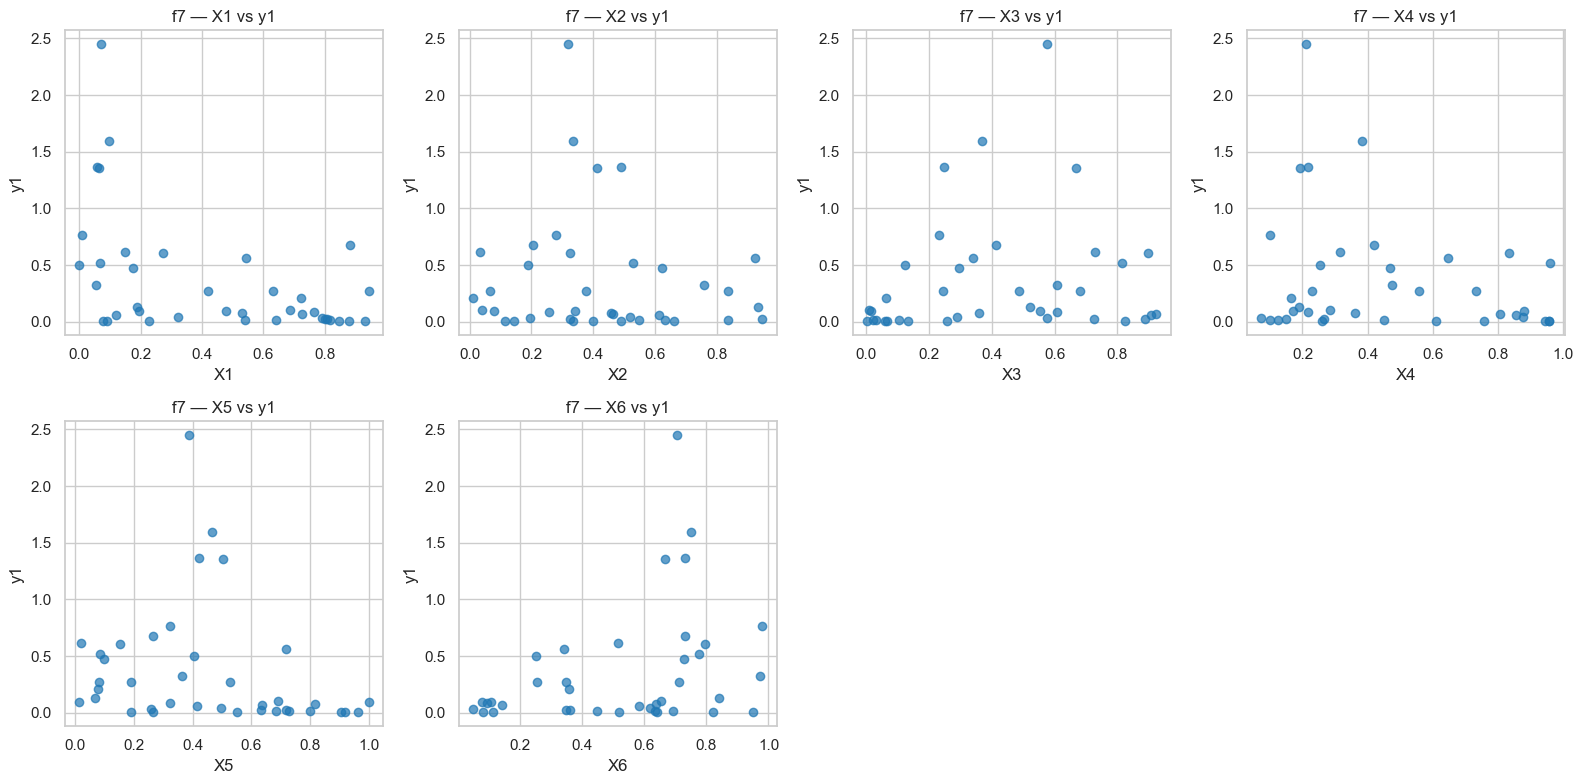


Feature vs Output Plots for f8
X shape for f8: (47, 8)
y shape for f8: (47,)


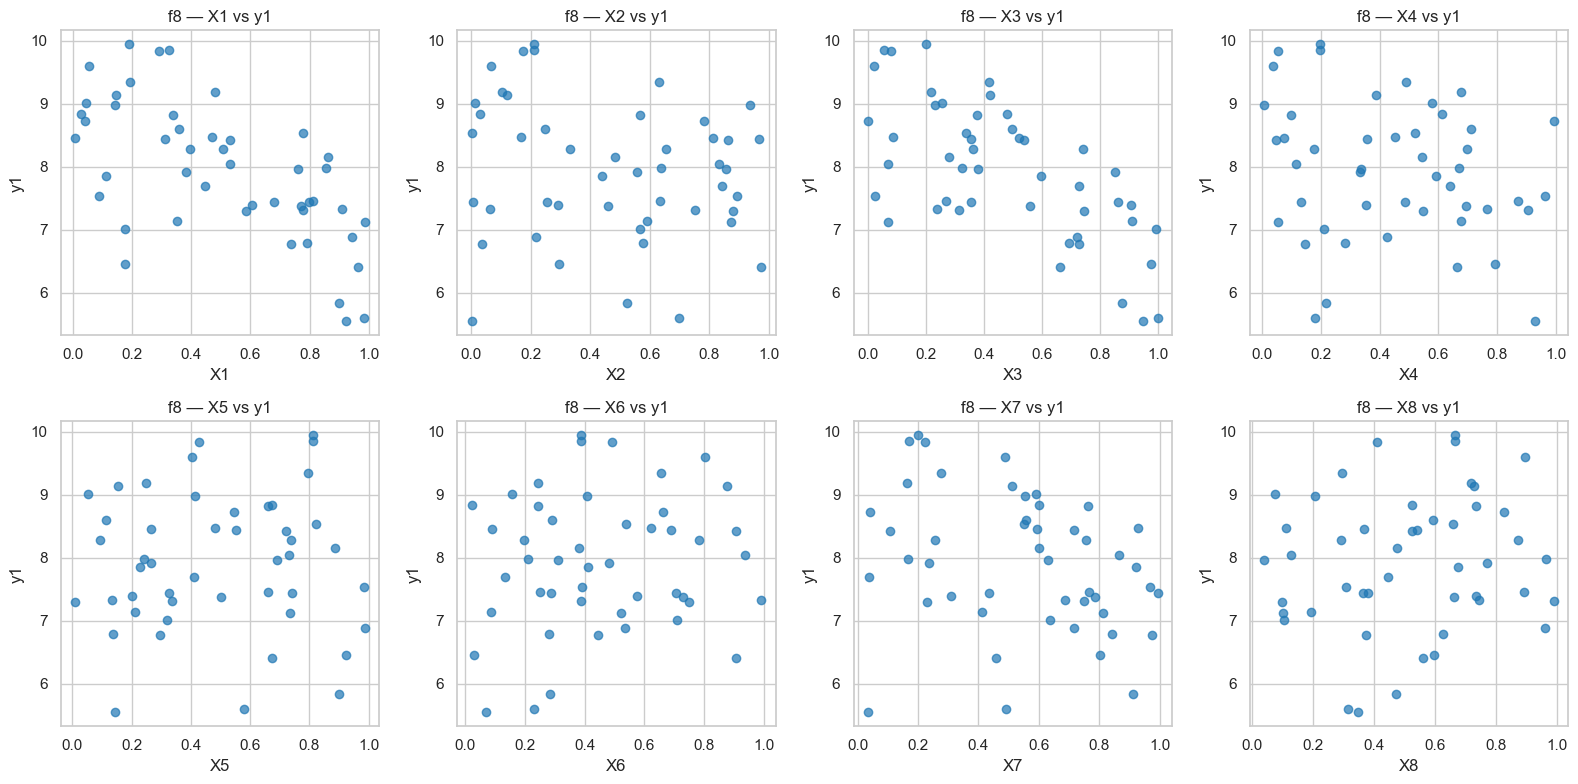

In [19]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")

    
    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot

    
    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



=== f1 — Feature & Output Distributions ===


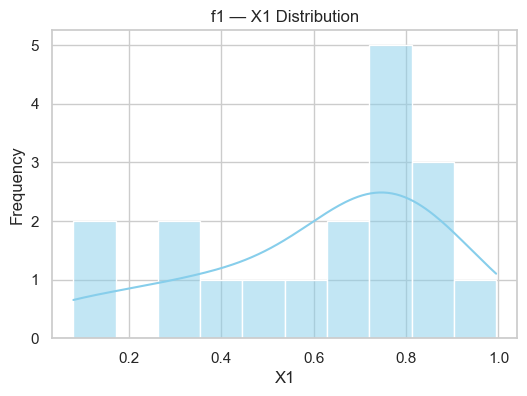

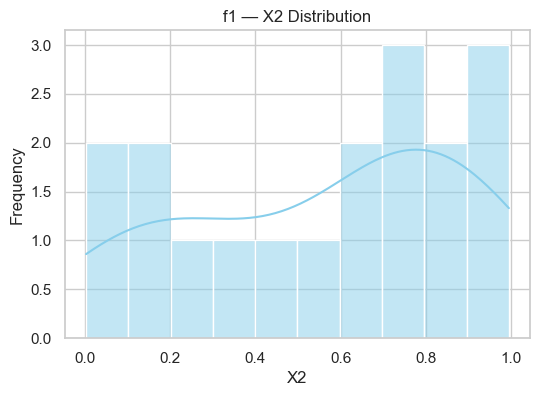

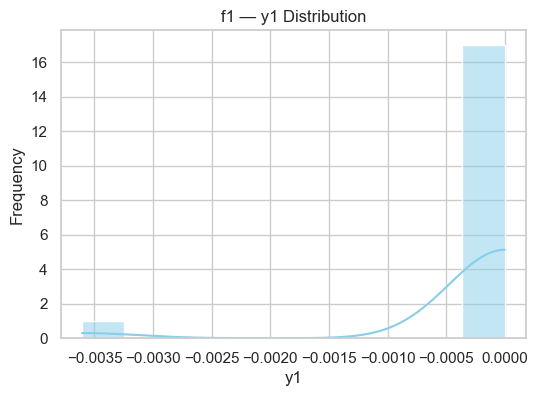


=== f2 — Feature & Output Distributions ===


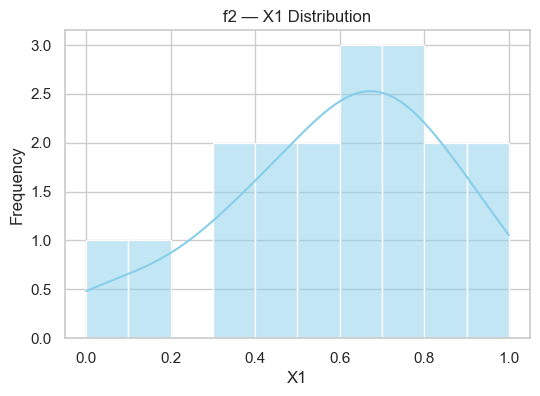

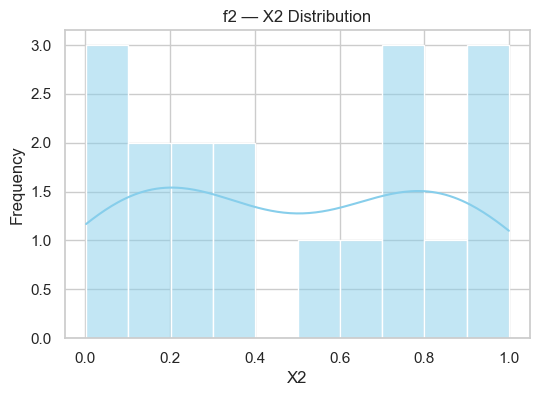

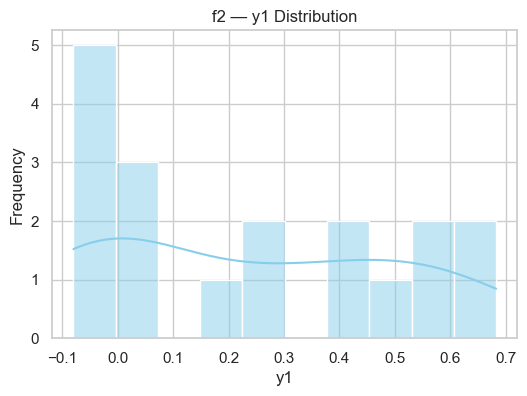


=== f3 — Feature & Output Distributions ===


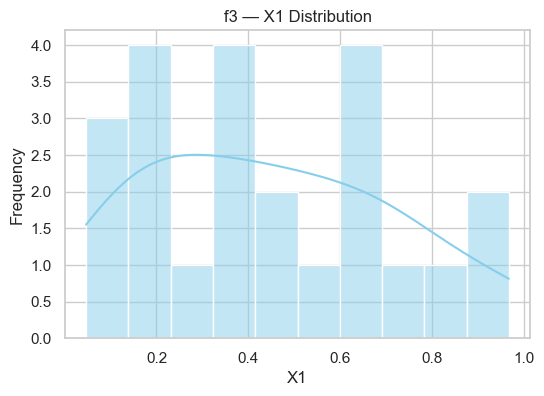

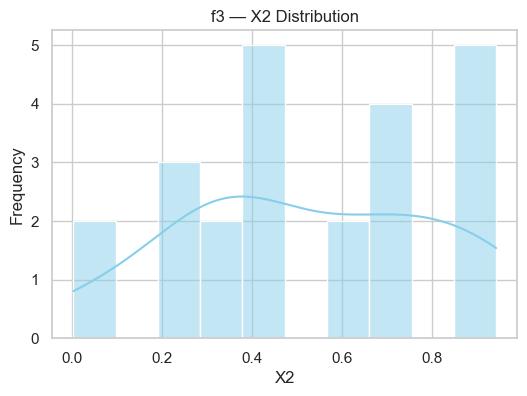

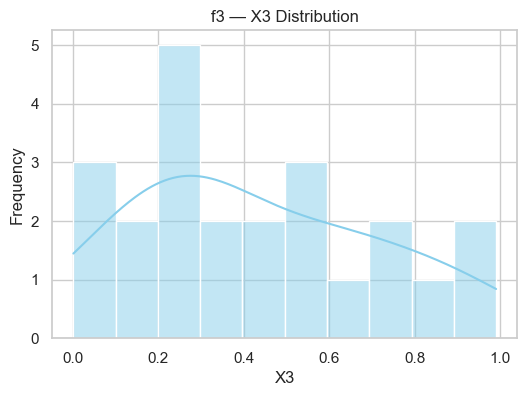

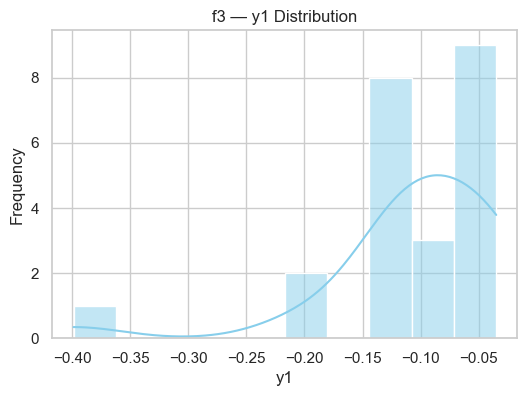


=== f4 — Feature & Output Distributions ===


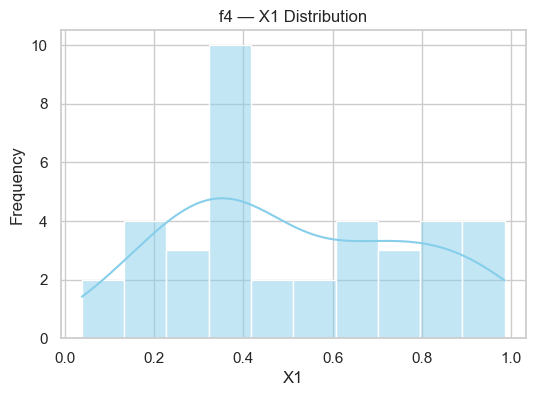

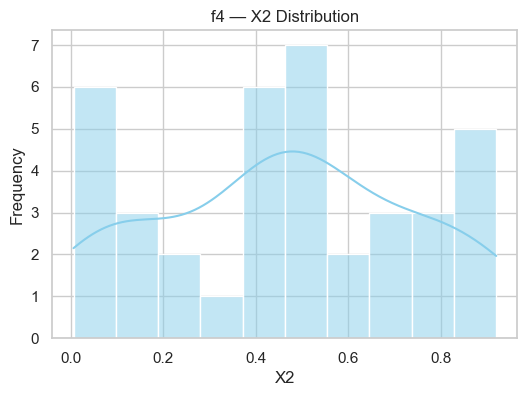

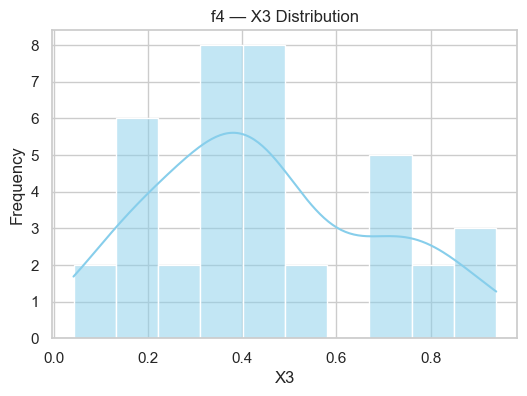

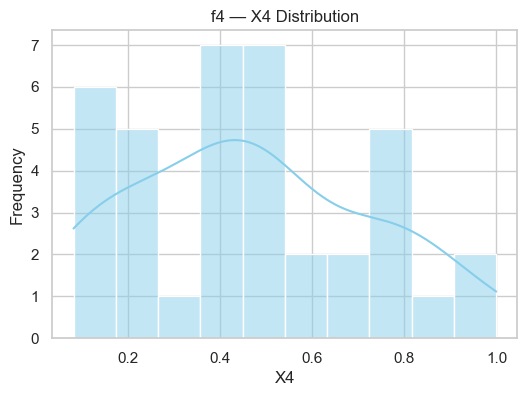

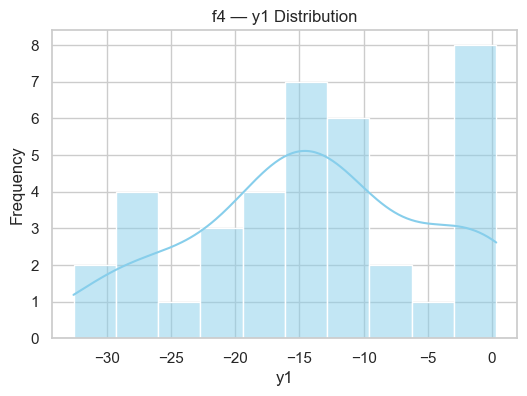


=== f5 — Feature & Output Distributions ===


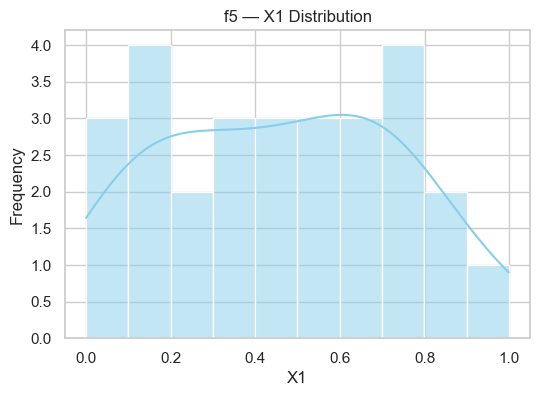

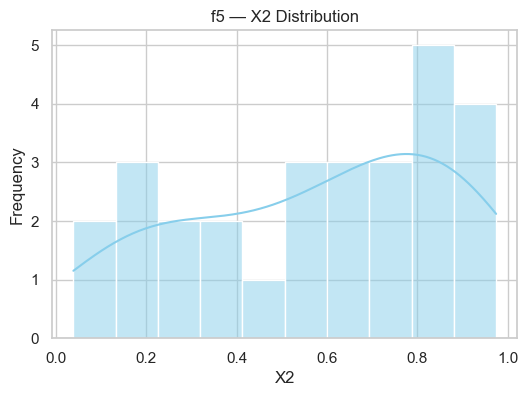

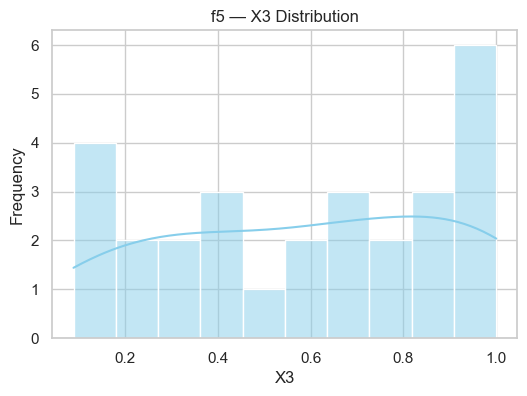

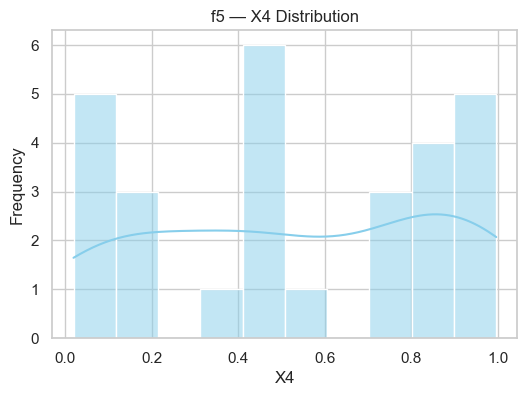

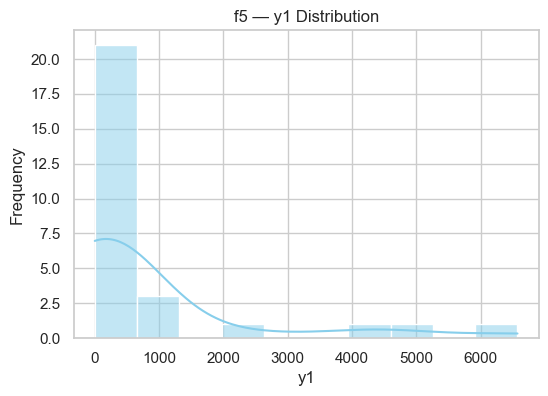


=== f6 — Feature & Output Distributions ===


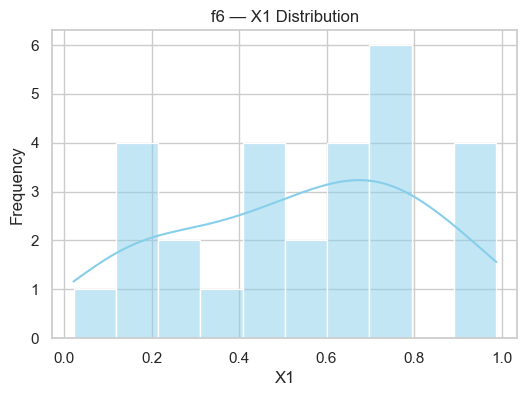

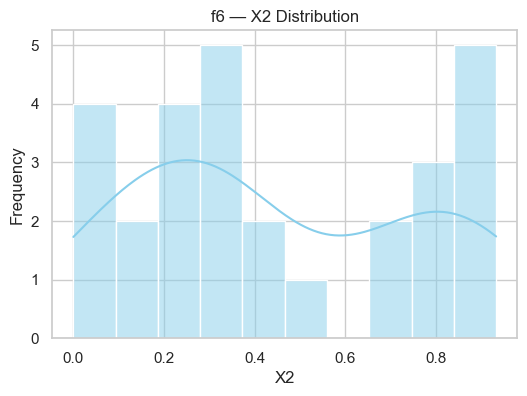

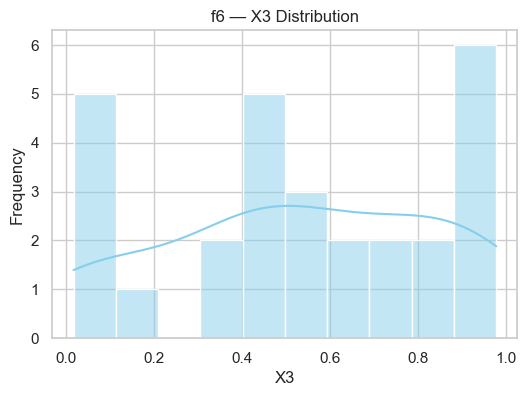

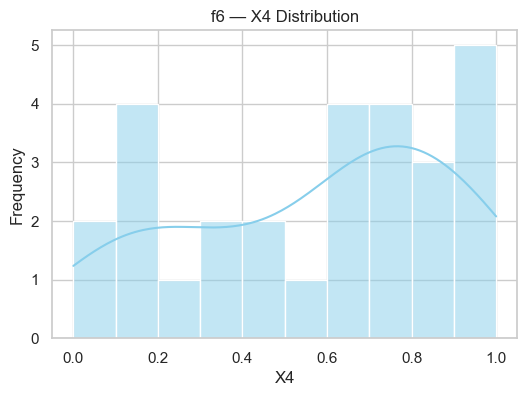

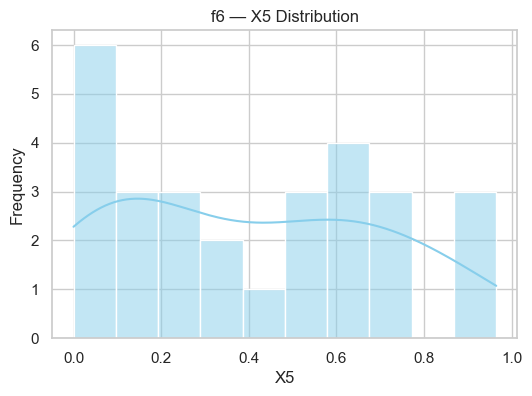

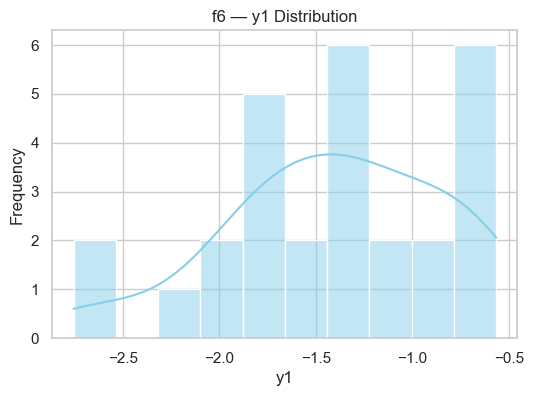


=== f7 — Feature & Output Distributions ===


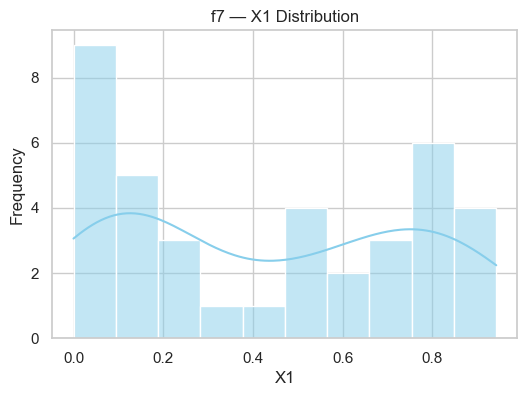

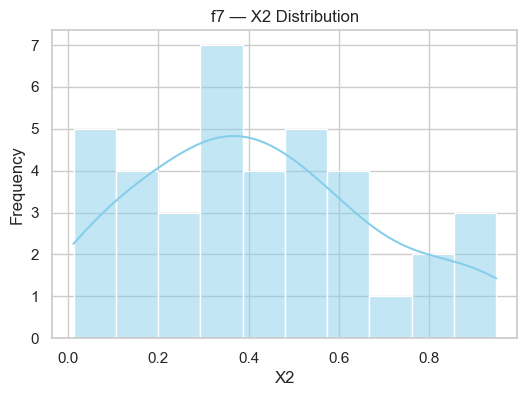

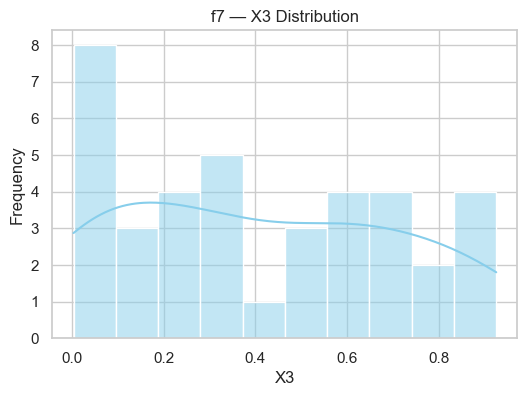

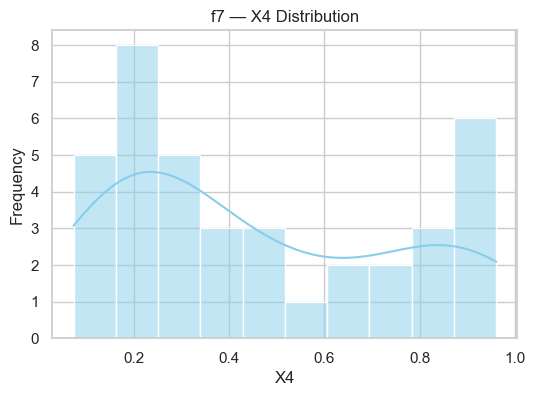

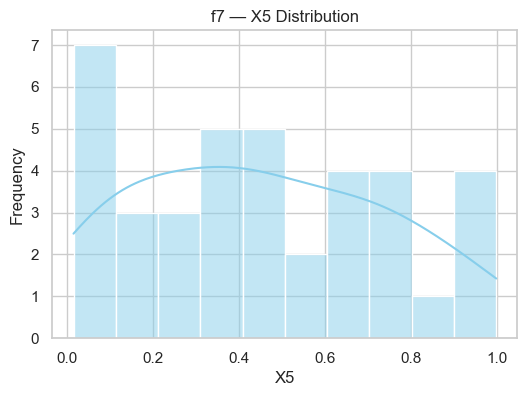

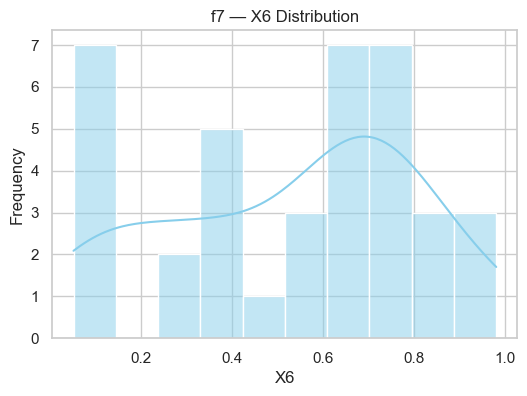

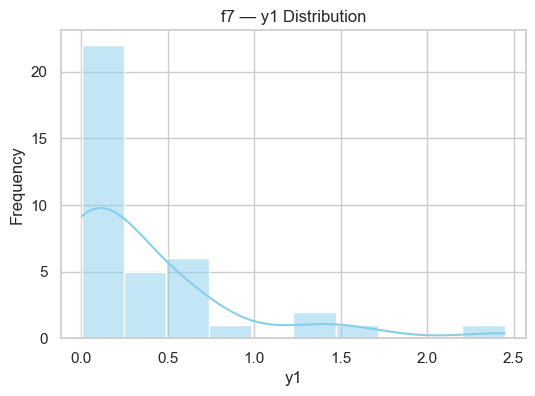


=== f8 — Feature & Output Distributions ===


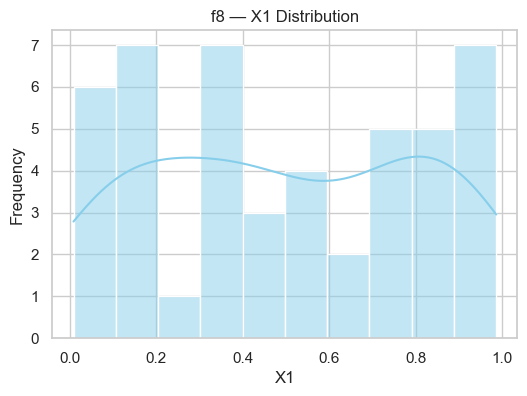

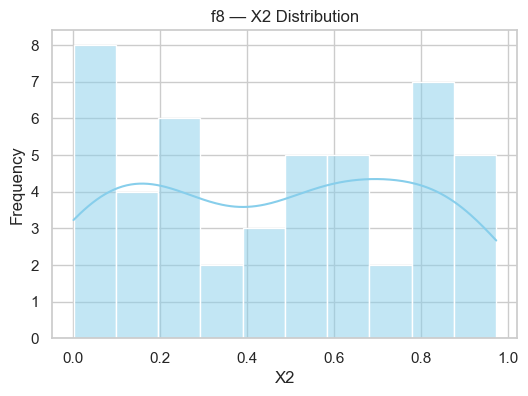

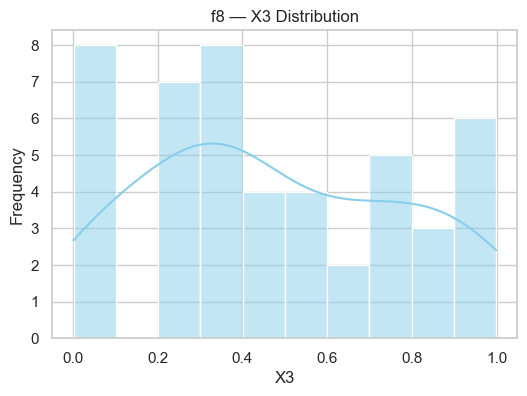

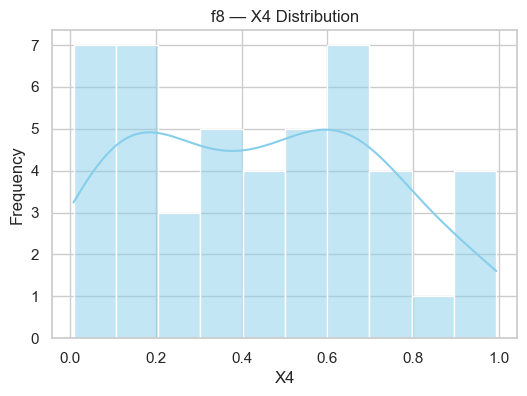

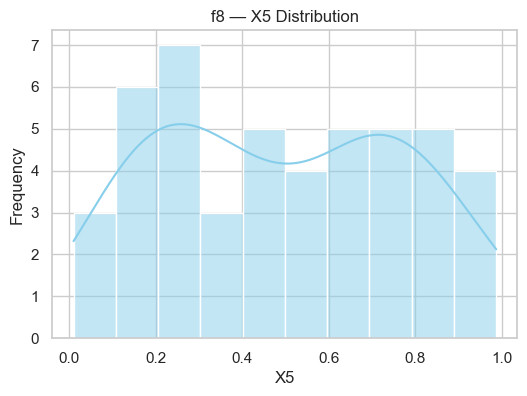

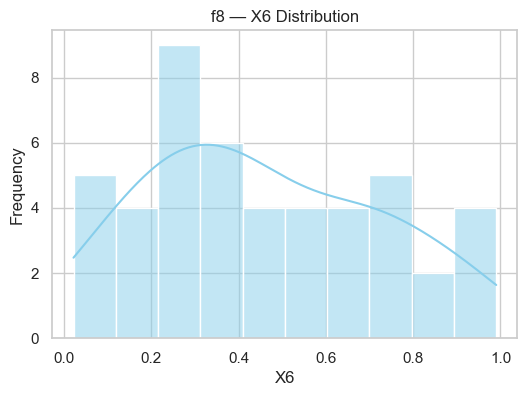

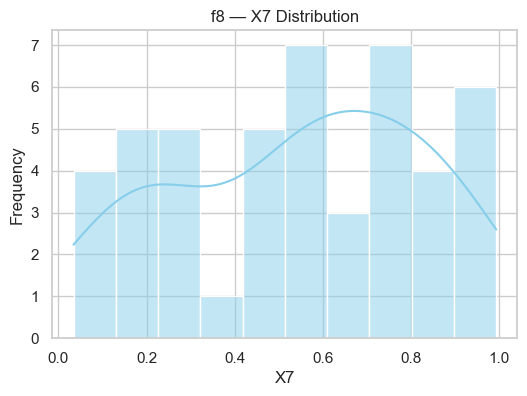

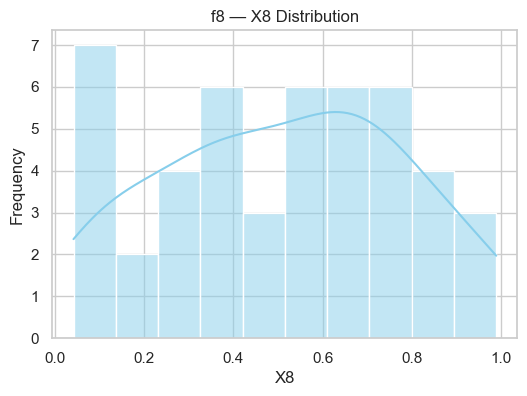

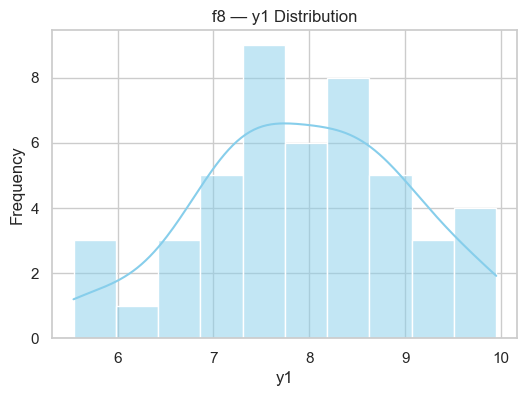

In [46]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
17  0.994902  0.994221  3.029971e-187

f1 — y vs Instance Plot


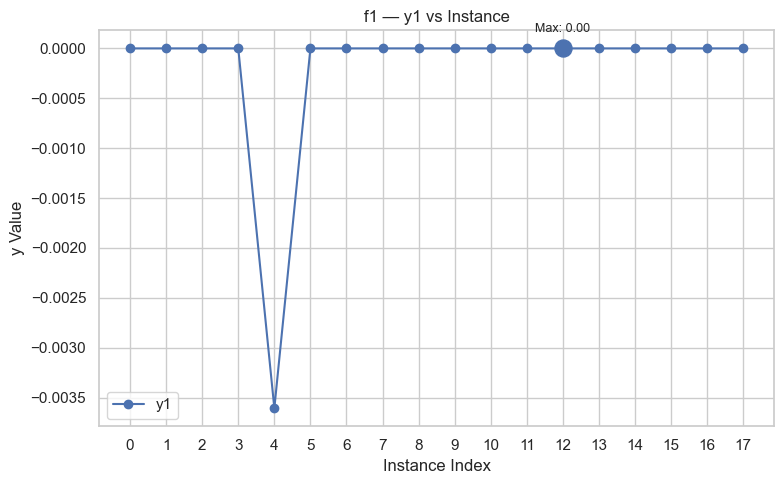


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452
15  0.653993  0.981188  0.379820
16  0.000128  0.346419  0.005941
17  0.920304  0.040061 -0.031746

f2 — y vs Instance Plot


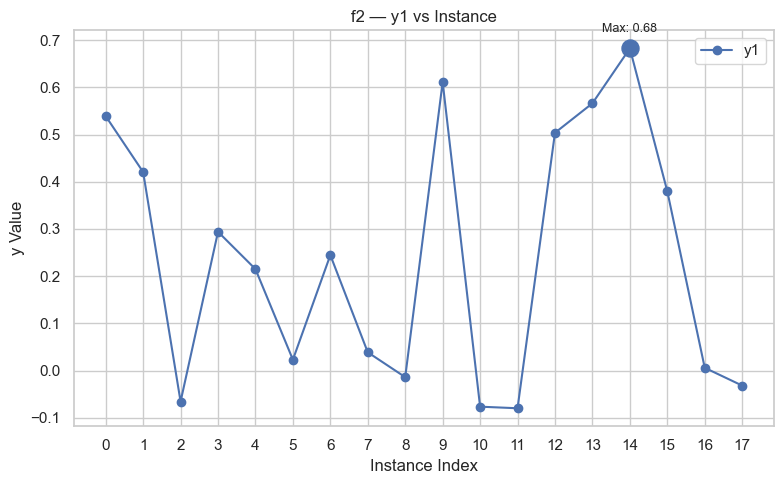


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375
21  0.110343  0.915465  0.655916

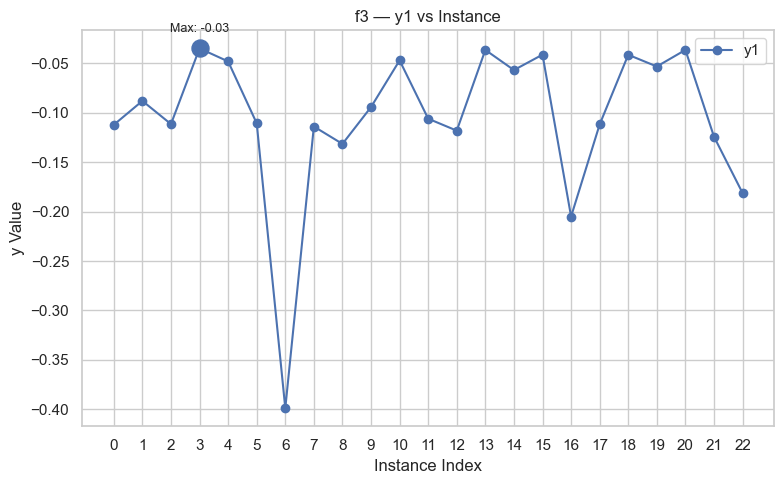


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

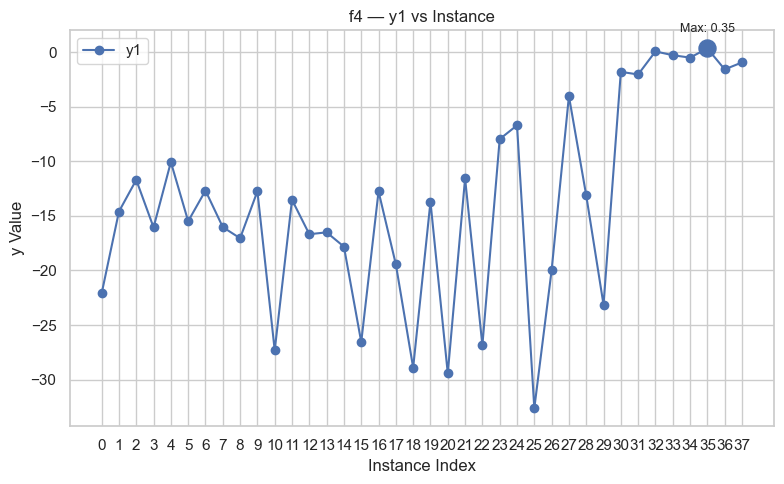


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

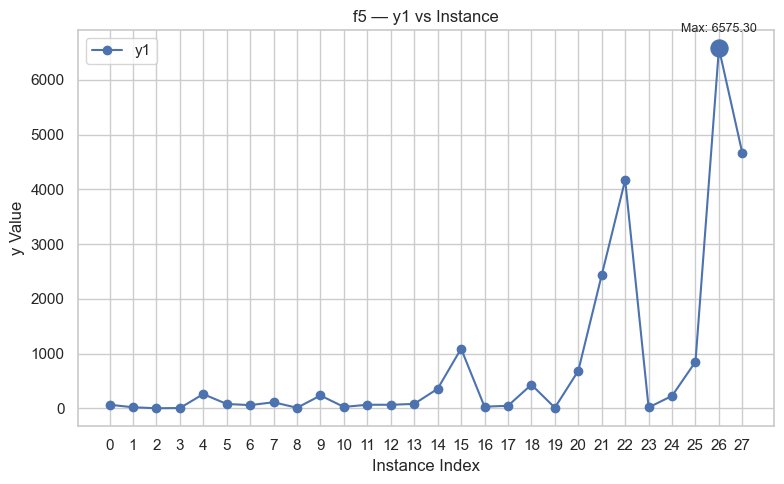


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

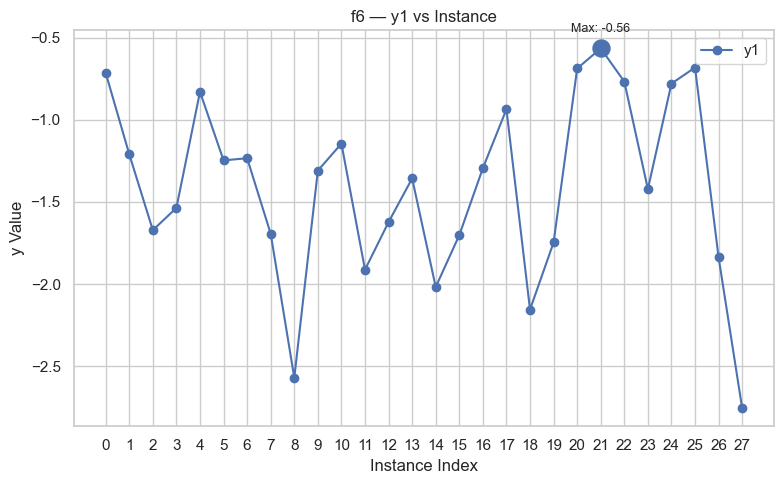


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

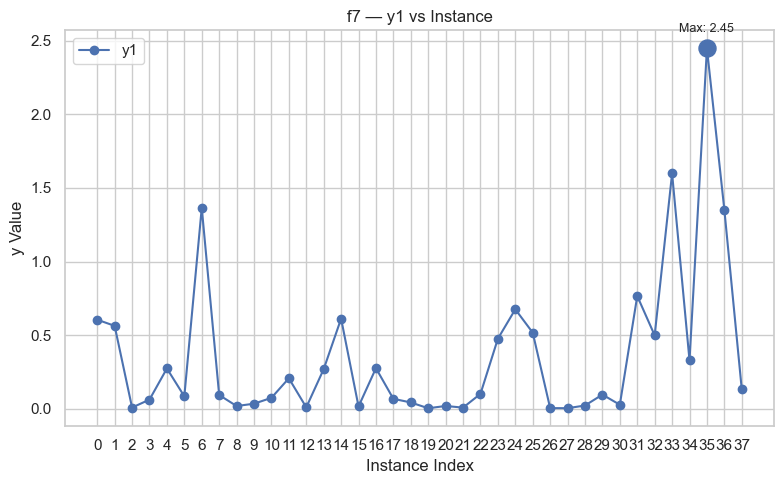


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

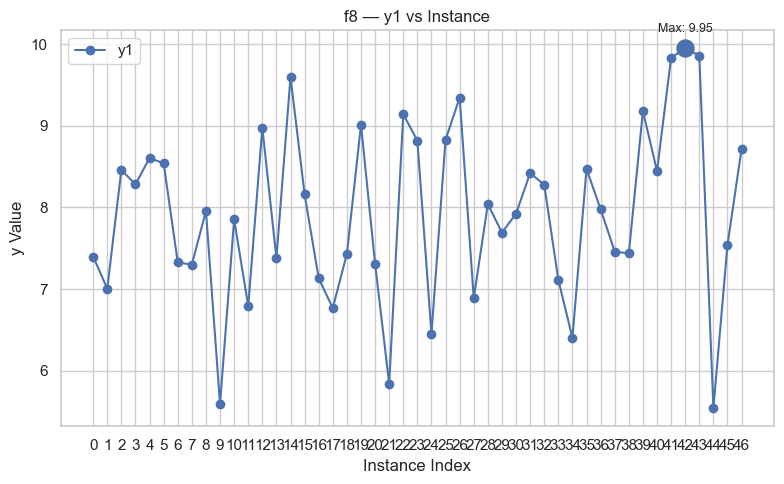

In [20]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | turbo 1 local BO with copula warped GP

In [21]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

In [22]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]
 [0.81265    0.143347  ]
 [0.079265   0.909848  ]
 [0.525569   0.987823  ]
 [0.994902   0.994221  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057 -1.06293312e-161  2.60788262e-248
  2.23603281e-098  3.02997127e-187]


In [23]:
# gaussian copula transform for y
# this uses ranks to map raw outputs to standard normal values
# this is important for f1 because raw outputs span many orders of magnitude
def gaussian_copula_transform(y):
    # number of observations
    n = len(y)
    # compute ranks from 1 to n
    ranks = np.argsort(np.argsort(y)) + 1
    # convert ranks to uniform quantiles in (0, 1)
    quantiles = ranks / (n + 1)
    # map quantiles to standard normal values
    y_copula = norm.ppf(quantiles)
    return y_copula

# standardise copula transformed outputs
# gaussian processes work best when targets have zero mean and unit variance
def standardise(y_copula):
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y_copula.reshape(-1, 1)).ravel()
    return y_scaled, scaler

# compute trust region bounds around the current best point
# the trust region is a box in [0,1]^2 with a given side length
def get_trust_region(centre, length, bounds=(0.0, 1.0)):
    lower = np.clip(centre - length / 2.0, bounds[0], bounds[1])
    upper = np.clip(centre + length / 2.0, bounds[0], bounds[1])
    return lower, upper

# generate uniform random candidates inside the trust region
# this is sufficient because the region is small and local
def generate_local_candidates(lower, upper, n_candidates=5000, seed=42):
    rng = np.random.default_rng(seed)
    candidates = rng.uniform(low=lower, high=upper, size=(n_candidates, len(lower)))
    return candidates

# apply a minimum distance guard to avoid near duplicate evaluations
# this ensures each new point adds new information
def apply_min_dist_guard(candidates, X_train, min_dist=0.02):
    dists = np.sqrt(((candidates[:, None, :] - X_train[None, :, :]) ** 2).sum(axis=2))
    min_dists = dists.min(axis=1)
    return candidates[min_dists >= min_dist]

# fit a gaussian process with matern kernel and white noise
# this models the local shape of the function in the transformed space
def fit_gp(X_train, y_scaled):
    kernel = (
        Matern(
            length_scale=[1.0, 1.0],
            length_scale_bounds=[(0.001, 2.0), (0.001, 2.0)],
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-10, 1.0)
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=False,
        alpha=1e-10,
        random_state=42
    )
    gp.fit(X_train, y_scaled)
    return gp

# compute expected improvement at candidate points
# xi is set to zero for pure exploitation inside the trust region
def expected_improvement(gp, candidates, y_scaled_best, xi=0.0):
    mu, sigma = gp.predict(candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_scaled_best - xi) / sigma
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
    return ei, mu, sigma

# update trust region length based on success or failure
# this follows the turbo rule: expand after success, shrink after failure
def update_trust_region(current_length, success,
                        expand_factor=1.5, shrink_factor=0.75,
                        min_length=0.005, max_length=0.30):
    if success:
        new_length = min(current_length * expand_factor, max_length)
        print(f"success: trust region expanded from {current_length:.4f} to {new_length:.4f}")
    else:
        new_length = max(current_length * shrink_factor, min_length)
        print(f"failure: trust region shrunk from {current_length:.4f} to {new_length:.4f}")
    return new_length

# print diagnostics to understand how the model and acquisition behave
def print_diagnostics(y_raw, y_copula, y_scaled, gp, candidates,
                      best_idx, ei_vals, mu_vals, sigma_vals,
                      trust_lower, trust_upper):
    print("\n--- f1 turbo 1 diagnostics ---")
    print(f"n observations: {len(y_raw)}")
    print(f"raw best y: {y_raw.max():.4e} at index {y_raw.argmax()}")
    print(f"copula range: [{y_copula.min():.3f}, {y_copula.max():.3f}]")
    print(f"scaled best: {y_scaled.max():.4f}")
    print("\n gp kernel after fitting:")
    print(f"  {gp.kernel_}")
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)
    print(f"  log marginal likelihood: {lml:.4f}")
    print(f"\ntrust region: x1 in [{trust_lower[0]:.4f}, {trust_upper[0]:.4f}]")
    print(f"              x2 in [{trust_lower[1]:.4f}, {trust_upper[1]:.4f}]")
    print(f"\ncandidates surviving distance guard: {len(candidates)}")
    print(f"fraction with ei > 0: {(ei_vals > 0).mean():.3f}")
    print(f"\nselected candidate: x1={candidates[best_idx][0]:.6f}, "
          f"x2={candidates[best_idx][1]:.6f}")
    print(f"gp mean at selection: {mu_vals[best_idx]:.4f}")
    print(f"gp std at selection:  {sigma_vals[best_idx]:.4f}")
    print(f"ei at selection:      {ei_vals[best_idx]:.6f}")

# main function to propose the next query for f1 using x_train_1 and y_train_1
def propose_f1_query(X_train_1, y_train_1, trust_region_length=0.10):
    print("=== f1 turbo 1 local bayesian optimisation with copula warped gp ===")

    # find current best point in the raw data
    best_idx_train = np.argmax(y_train_1)
    best_x = X_train_1[best_idx_train]
    best_y = y_train_1[best_idx_train]
    print(f"current best: y={best_y:.4e} at x1={best_x[0]:.6f}, x2={best_x[1]:.6f}")

    # apply gaussian copula transform to raw outputs
    y_copula = gaussian_copula_transform(y_train_1)

    # standardise the copula transformed outputs
    y_scaled, scaler = standardise(y_copula)
    y_scaled_best = y_scaled[best_idx_train]

    # fit gaussian process on all training data
    gp = fit_gp(X_train_1, y_scaled)

    # define trust region around the current best point
    trust_lower, trust_upper = get_trust_region(
        centre=best_x,
        length=trust_region_length
    )

    # generate local candidates inside the trust region
    candidates = generate_local_candidates(
        lower=trust_lower,
        upper=trust_upper,
        n_candidates=5000
    )

    # remove candidates that are too close to existing points
    candidates = apply_min_dist_guard(candidates, X_train_1, min_dist=0.02)

    # if all candidates are removed, relax the distance threshold
    if len(candidates) == 0:
        print("warning: all candidates removed by distance guard, relaxing to 0.01")
        candidates = generate_local_candidates(trust_lower, trust_upper, n_candidates=5000)
        candidates = apply_min_dist_guard(candidates, X_train_1, min_dist=0.01)

    # compute expected improvement with xi equal to zero
    ei_vals, mu_vals, sigma_vals = expected_improvement(
        gp, candidates, y_scaled_best, xi=0.0
    )

    # select candidate with highest expected improvement
    selected_idx = np.argmax(ei_vals)
    next_x = candidates[selected_idx]

    # print diagnostics for understanding
    print_diagnostics(
        y_train_1, y_copula, y_scaled, gp,
        candidates, selected_idx, ei_vals, mu_vals, sigma_vals,
        trust_lower, trust_upper
    )

    print(f"\nrecommended next point for f1: x1={next_x[0]:.6f}, x2={next_x[1]:.6f}")

    # return the next query point and the current trust region length
    return next_x, trust_region_length

next_x = propose_f1_query(X_train_1, y_train_1)


=== f1 turbo 1 local bayesian optimisation with copula warped gp ===
current best: y=5.3146e-15 at x1=0.729726, x2=0.729276

--- f1 turbo 1 diagnostics ---
n observations: 18
raw best y: 5.3146e-15 at index 12
copula range: [-1.620, 1.620]
scaled best: 1.8868

 gp kernel after fitting:
  Matern(length_scale=[2, 0.00801], nu=2.5) + WhiteKernel(noise_level=6.58e-09)
  log marginal likelihood: -23.1424

trust region: x1 in [0.6797, 0.7797]
              x2 in [0.6793, 0.7793]

candidates surviving distance guard: 4261
fraction with ei > 0: 0.988

selected candidate: x1=0.684583, x2=0.725353
gp mean at selection: 1.6540
gp std at selection:  0.4641
ei at selection:      0.091585

recommended next point for f1: x1=0.684583, x2=0.725353


#### f2 | ARD-GP UCB with Tight Active-Region Candidate Concentration

In [24]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [5.54975000e-01 9.99446000e-01]
 [9.99500000e-01 1.80000000e-03]
 [7.27681000e-01 1.87140000e-01]
 [7.15483000e-01 5.63901000e-01]
 [6.78746000e-01 8.50809000e-01]
 [6.53993000e-01 9.81188000e-01]
 [1.28000000e-04 3.46419000e-01]
 [9.20304000e-01 4.00610000e-02]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322  0.56616625  0.68245235  0.37981981  0.00594097 -0.03174629]


In [25]:
from scipy.stats import qmc
from scipy.spatial.distance import cdist
from sklearn.gaussian_process.kernels import RBF

In [26]:
# this function fits a gaussian process on x_train_2 and y_train_2
# and uses gp ucb with a soft gaussian spatial weight to select
# the next query point for function 2
def propose_f2_query(X_train_2, y_train_2):
    print("f2 week 9: ard gp ucb with soft gaussian active region focus")

    # section 1: fit the gaussian process surrogate
    # rbf kernel with separate length scales for x1 and x2
    # whitekernel models observation noise and keeps uncertainty honest
    kernel = (
        1.0 * RBF(
            length_scale=[0.5, 1.0],
            length_scale_bounds=[(0.05, 3.0), (0.10, 5.0)]
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 0.3)
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=20,
        normalize_y=True,
        random_state=42
    )

    gp.fit(X_train_2, y_train_2)
    print("fitted kernel:", gp.kernel_)
    print("log marginal likelihood:", gp.log_marginal_likelihood_value_)

    # section 2: generate sobol candidates in [0,1]^2
    # sobol sequence gives uniform coverage of the domain
    sobol_engine = qmc.Sobol(d=2, scramble=True, seed=42)
    candidates = sobol_engine.random_base2(m=13)  # 8192 candidates

    # section 3: apply minimum distance guard
    # remove candidates that are too close to existing points
    MIN_DIST = 0.05
    dists = cdist(candidates, X_train_2)
    mask_far = dists.min(axis=1) >= MIN_DIST
    candidates = candidates[mask_far]
    print(f"candidates after min dist guard: {len(candidates)}")

    # section 4: define soft gaussian spatial weight
    # centre is the centroid of the top three observations
    # sigmas control how quickly the weight decays away from the centre
    CENTRE_X1 = 0.699
    CENTRE_X2 = 0.780
    SIGMA_X1 = 0.12
    SIGMA_X2 = 0.15

    def soft_weight(cands, cx1, cx2, sx1, sx2):
        # gaussian weight high near (cx1, cx2) and lower farther away
        w1 = np.exp(-0.5 * ((cands[:, 0] - cx1) / sx1) ** 2)
        w2 = np.exp(-0.5 * ((cands[:, 1] - cx2) / sx2) ** 2)
        return w1 * w2

    weights = soft_weight(
        candidates, CENTRE_X1, CENTRE_X2, SIGMA_X1, SIGMA_X2
    )

    # section 5: compute gp ucb acquisition
    # ucb = mu + beta * sigma, with beta controlling exploration strength
    BETA = 2.0
    mu, sigma = gp.predict(candidates, return_std=True)
    ucb = mu + BETA * sigma

    # normalise ucb to [0,1] so that the product with weights is stable
    ucb_norm = (ucb - ucb.min()) / (ucb.max() - ucb.min() + 1e-12)

    # combined score reflects both model based exploration and spatial prior
    combined_score = ucb_norm * weights

    # section 6: select the best candidate
    best_idx = np.argmax(combined_score)
    next_point = candidates[best_idx]

    print("\nweek 9 f2 selected candidate")
    print(f"x1: {next_point[0]:.6f}")
    print(f"x2: {next_point[1]:.6f}")
    print(f"gp mean at candidate:  {mu[best_idx]:.6f}")
    print(f"gp sigma at candidate: {sigma[best_idx]:.6f}")
    print(f"ucb score:             {ucb[best_idx]:.6f}")
    print(f"soft weight:           {weights[best_idx]:.6f}")
    print(f"combined score:        {combined_score[best_idx]:.6f}")

    # print current best for context
    best_idx_train = np.argmax(y_train_2)
    print(f"\ncurrent best y: {y_train_2[best_idx_train]:.6f} "
          f"at x = {X_train_2[best_idx_train]}")

    # optional: inspect top 5 candidates by combined score
    top5 = np.argsort(combined_score)[::-1][:5]
    print("\ntop 5 candidates by combined score:")
    print(f"{'rank':<5} {'x1':<8} {'x2':<8} {'mu':<10} {'sigma':<10} {'weight':<10}")
    for r, i in enumerate(top5, 1):
        print(
            f"{r:<5} {candidates[i,0]:<8.4f} {candidates[i,1]:<8.4f} "
            f"{mu[i]:<10.4f} {sigma[i]:<10.4f} {weights[i]:<10.4f}"
        )

    # optional: count candidates in the unmapped x2 gap
    gap_mask = (
        (candidates[:, 0] >= 0.65) & (candidates[:, 0] <= 0.75) &
        (candidates[:, 1] >= 0.55) & (candidates[:, 1] <= 0.80)
    )
    gap_candidates = candidates[gap_mask]
    print(f"\ncandidates in unmapped x2 gap "
          f"[0.65-0.75 x1, 0.55-0.80 x2]: {len(gap_candidates)}")
    if len(gap_candidates) > 0:
        gap_scores = combined_score[gap_mask]
        best_gap_idx = np.argmax(gap_scores)
        print(f"best gap candidate: x1={gap_candidates[best_gap_idx,0]:.4f}, "
              f"x2={gap_candidates[best_gap_idx,1]:.4f}")

    # return the selected next query point
    return next_point
    
np.set_printoptions(suppress=True, precision=10)
next_x = propose_f2_query(X_train_2, y_train_2)


f2 week 9: ard gp ucb with soft gaussian active region focus
fitted kernel: 0.973**2 * RBF(length_scale=[0.05, 5]) + WhiteKernel(noise_level=0.0482)
log marginal likelihood: -17.287154526025056
candidates after min dist guard: 7217

week 9 f2 selected candidate
x1: 0.695009
x2: 0.789642
gp mean at candidate:  0.637447
gp sigma at candidate: 0.068293
ucb score:             0.774033
soft weight:           0.997385
combined score:        0.978961

current best y: 0.682452 at x = [0.678746 0.850809]

top 5 candidates by combined score:
rank  x1       x2       mu         sigma      weight    
1     0.6950   0.7896   0.6374     0.0683     0.9974    
2     0.6975   0.7800   0.6358     0.0681     0.9999    
3     0.6996   0.7820   0.6330     0.0679     0.9999    
4     0.6893   0.7721   0.6347     0.0683     0.9954    
5     0.6929   0.7616   0.6377     0.0683     0.9912    

candidates in unmapped x2 gap [0.65-0.75 x1, 0.55-0.80 x2]: 165
best gap candidate: x1=0.6950, x2=0.7896


#### f3 | Kernel Ridge Mean with Fixed-Hyperparameter GP Uncertainty

In [27]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[0.1715252069 0.3439168703 0.2487372011]
 [0.2421144606 0.6440742698 0.2724328092]
 [0.5349057202 0.3985009154 0.1733887289]
 [0.4925814146 0.6115931883 0.340176386 ]
 [0.1346216663 0.2199172405 0.4582062196]
 [0.3455232705 0.9413598306 0.2693634791]
 [0.1518366324 0.439990619  0.9908818666]
 [0.6455028352 0.3971429396 0.9197713377]
 [0.7469119452 0.2841963092 0.2262998549]
 [0.170476994  0.6970324007 0.1491694337]
 [0.2205493371 0.2978252442 0.3435553444]
 [0.6660136588 0.6719851513 0.2462952967]
 [0.0468089497 0.2313602408 0.7706175922]
 [0.6000972824 0.7251357252 0.0660886415]
 [0.9659948489 0.8611196897 0.5668291313]
 [0.389233     0.386084     0.558916    ]
 [0.9672       0.0292       0.7233      ]
 [0.437962     0.715305     0.000876    ]
 [0.387933     0.40524      0.580181    ]
 [0.688252     0.924125     0.842251    ]
 [0.788392     0.913423     0.40309     ]
 [0.110343     0.915465     0.655916    ]
 [0.394618     0.003779     0.001514    ]]
[-0.1121222005 -0.0879628602 -0.1

In [28]:
from sklearn.gaussian_process.kernels import ConstantKernel as C 
from scipy.stats.qmc import Sobol
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

In [29]:
# this function implements the f3 week 9 strategy
# it uses kernel ridge regression for the mean
# and a fixed hyperparameter gaussian process for uncertainty
# the acquisition is upper confidence bound using mean and sigma

def propose_f3_query(X_train_3, y_train_3):
    print("f3 week 9: krr mean + fixed gp uncertainty with ucb")

    rng = np.random.default_rng(seed=7)

    # step 1: tune kernel ridge regression by leave one out cross validation
    # this chooses alpha and gamma that minimise prediction error
    alpha_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0]
    gamma_grid = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

    loo = LeaveOneOut()
    best_mse = np.inf
    best_alpha = 0.01
    best_gamma = 2.0

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            # create a kernel ridge model with given alpha and gamma
            krr = KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
            preds = []
            trues = []
            # leave one out: train on n minus 1 points, validate on the held out point
            for train_idx, val_idx in loo.split(X_train_3):
                krr.fit(X_train_3[train_idx], y_train_3[train_idx])
                preds.append(krr.predict(X_train_3[val_idx])[0])
                trues.append(y_train_3[val_idx][0])
            mse = mean_squared_error(trues, preds)
            if mse < best_mse:
                best_mse = mse
                best_alpha = alpha
                best_gamma = gamma

    print("best krr alpha:", best_alpha)
    print("best krr gamma:", best_gamma)
    print("best loo mse:", best_mse)

    # fit final kernel ridge model on all data
    krr = KernelRidge(kernel="rbf", alpha=best_alpha, gamma=best_gamma)
    krr.fit(X_train_3, y_train_3)

    # step 2: fit gaussian process with fixed hyperparameters for uncertainty
    # hyperparameters are chosen from eda and kept in tight bounds
    kernel = (
        C(1.0, (0.8, 1.2)) *
        Matern(
            length_scale=[5.0, 0.4, 0.35],
            length_scale_bounds=[
                (4.0, 8.0),    # x1 long scale, mostly irrelevant
                (0.25, 0.70),  # x2 moderate active dimension
                (0.20, 0.60)   # x3 moderate active dimension
            ],
            nu=2.5
        )
        + WhiteKernel(
            noise_level=0.012,
            noise_level_bounds=(0.008, 0.020)
        )
    )

    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        alpha=0.0
    )
    gp.fit(X_train_3, y_train_3)
    print("fitted gp kernel:", gp.kernel_)

    # step 3: generate candidates in three basins and a sobol arm
    # basin a around best observed region
    x2_a = np.linspace(0.45, 0.75, 6)
    x3_a = np.linspace(0.05, 0.48, 6)
    x2_ga, x3_ga = np.meshgrid(x2_a, x3_a)
    basin_a = np.column_stack([
        rng.uniform(0.0, 1.0, x2_ga.size),
        x2_ga.flatten(),
        x3_ga.flatten()
    ])

    # basin b around high x2 moderate x3 region
    x2_b = np.linspace(0.75, 0.98, 5)
    x3_b = np.linspace(0.30, 0.58, 5)
    x2_gb, x3_gb = np.meshgrid(x2_b, x3_b)
    basin_b = np.column_stack([
        rng.uniform(0.0, 1.0, x2_gb.size),
        x2_gb.flatten(),
        x3_gb.flatten()
    ])

    # basin c around very low x3 region
    x2_c = np.linspace(0.60, 0.85, 5)
    x3_c = np.linspace(0.02, 0.15, 5)
    x2_gc, x3_gc = np.meshgrid(x2_c, x3_c)
    basin_c = np.column_stack([
        rng.uniform(0.0, 1.0, x2_gc.size),
        x2_gc.flatten(),
        x3_gc.flatten()
    ])

    # sobol arm constrained to structural bounds
    sampler = Sobol(d=3, scramble=True, seed=42)
    sobol_raw = sampler.random_base2(m=10)
    sobol_constrained = sobol_raw[
        (sobol_raw[:, 1] >= 0.35) &
        (sobol_raw[:, 2] <= 0.60)
    ]

    # combine all candidates and clip to [0,1]^3
    all_candidates = np.vstack([basin_a, basin_b, basin_c, sobol_constrained])
    all_candidates = np.clip(all_candidates, 0.0, 1.0)

    # step 4: apply minimum distance filter to avoid near duplicates
    def min_dist(x, X):
        # compute minimum euclidean distance from x to any point in X
        return np.min(np.linalg.norm(X - x, axis=1))

    mask = np.array([min_dist(c, X_train_3) > 0.05 for c in all_candidates])
    filtered = all_candidates[mask]

    if len(filtered) < 20:
        mask = np.array([min_dist(c, X_train_3) > 0.03 for c in all_candidates])
        filtered = all_candidates[mask]

    print("candidates after distance filter:", len(filtered))

    # step 5: compute ucb using krr mean and gp sigma
    mu_krr = krr.predict(filtered)
    _, sigma_gp = gp.predict(filtered, return_std=True)

    beta = 2.5
    ucb_scores = mu_krr + beta * sigma_gp

    # step 6: enforce structural constraints as final gate
    struct_mask = (filtered[:, 1] >= 0.35) & (filtered[:, 2] <= 0.62)
    if struct_mask.sum() >= 10:
        filtered = filtered[struct_mask]
        mu_krr = mu_krr[struct_mask]
        sigma_gp = sigma_gp[struct_mask]
        ucb_scores = ucb_scores[struct_mask]

    # select candidate with highest ucb
    best_idx = np.argmax(ucb_scores)
    next_x = filtered[best_idx]
    next_mu = mu_krr[best_idx]
    next_sigma = sigma_gp[best_idx]
    next_ucb = ucb_scores[best_idx]

    print("structural check: x2={:.4f}, x3={:.4f}".format(next_x[1], next_x[2]))
    print("selected next query for f3:", next_x)
    print("krr mean at candidate:", next_mu)
    print("gp sigma at candidate:", next_sigma)
    print("ucb score at candidate:", next_ucb)

    return next_x, next_mu, next_sigma, next_ucb

next_x = propose_f3_query(X_train_3, y_train_3)

f3 week 9: krr mean + fixed gp uncertainty with ucb
best krr alpha: 0.1
best krr gamma: 2.0
best loo mse: 0.006716728049908779
fitted gp kernel: 1.1**2 * Matern(length_scale=[4, 0.25, 0.2], nu=2.5) + WhiteKernel(noise_level=0.02)
candidates after distance filter: 482
structural check: x2=0.9647, x3=0.0009
selected next query for f3: [0.9052620642 0.9647138203 0.0008922825]
krr mean at candidate: -0.03963895698442639
gp sigma at candidate: 0.06909735302015511
ucb score at candidate: 0.13310442556596142


#### f4 | Local ARD-GP + with expected improvement and restricted trust region

In [30]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.8969810544 0.7256279703 0.1754043089 0.7016943694]
 [0.8893563957 0.4995878554 0.5392688578 0.5087834391]
 [0.2509462428 0.0336931305 0.1453800247 0.4949324206]
 [0.3469620609 0.0062504002 0.7605636064 0.6130235572]
 [0.1248711812 0.1297701931 0.384400483  0.2870761011]
 [0.8013027073 0.5002310937 0.70664456   0.195102841 ]
 [0.2477082619 0.0604454273 0.0421863451 0.4413242505]
 [0.7467022421 0.7570915044 0.3693530596 0.206566281 ]
 [0.4006650272 0.0725742511 0.8867682538 0.2438422898]
 [0.6260705962 0.5867512593 0.4388057822 0.7788576938]
 [0.9571352931 0.597644383  0.7661138516 0.7762099053]
 [0.732812426  0.145249979  0.4768127176 0.133365734 ]
 [0.6551154792 0.0723918269 0.6871517458 0.0815165642]
 [0.2197344292 0.8320313351 0.4828641625 0.0825692306]
 [0.4885941895 0.2119650956 0.9391779074 0.3761917259]
 [0.1671304856 0.8765545583 0.217239545  0.9598009846]
 [0.2169111881 0.166085829  0.2413722564 0.7700624757]
 [0.3874878367 0.8045322582 0.7517954828 0.7238274385]
 [0.985621

In [31]:
from scipy.stats import qmc
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from scipy.stats import norm

In [32]:
def propose_f4_query(X_train_4, y_train_4):
    """
    ml method name:
      gaussian process regression with matern kernel in a 2d active subspace
      combined with expected improvement acquisition

    objective of submission:
      choose one new point for f4 that has a high chance of improving
      on the current best value while respecting the expensive nature
      of the black box function

    rationale behind the chosen ml method:
      gaussian processes provide a probabilistic model of the function
      with both mean and uncertainty. expected improvement uses this
      information to focus on points that can realistically beat the
      current best. restricting the gp to the active subspace (x2, x4)
      makes the model more stable and better aligned with the observed
      structure of f4

    key assumptions:
      x1 and x3 are locally flat near the best point and can be fixed
      x2 and x4 are the active dimensions that control local variation
      the optimum lies within a local trust region around the best point

    how the exploration mechanism operates:
      the gp is fitted only on the top local observations projected
      into the x2 x4 plane. expected improvement is computed over a
      dense sobol grid and refined by gradient based search in this
      2d plane. x1 and x3 remain fixed at their best values, so all
      movement happens along x2 and x4 where the gp sees structure
    """

    # step 0: basic checks
    X_train_4 = np.asarray(X_train_4, dtype=float)
    y_train_4 = np.asarray(y_train_4, dtype=float).ravel()
    assert X_train_4.shape[1] == 4, "X_train_4 must have shape (n_samples, 4)"

    # step 1: identify current best point
    # this is the reference point for the trust region and for fixing x1 and x3
    best_idx = np.argmax(y_train_4)
    x_best = X_train_4[best_idx]
    y_best = y_train_4[best_idx]

    print(f"current best: {np.round(x_best, 4)}, y = {y_best:.6f}")

    # step 2: select top local observations for gp fitting
    # we use the top 12 points by y value to represent the plateau region
    n_local = min(12, len(y_train_4))
    top_idx = np.argsort(y_train_4)[-n_local:]
    X_local = X_train_4[top_idx]
    y_local = y_train_4[top_idx]

    print(f"local y range: [{y_local.min():.4f}, {y_local.max():.4f}]")
    print(f"local sample size: {n_local}")

    # step 3: project onto active subspace (x2, x4)
    # x1 and x3 are fixed at the current best values
    x1_fixed = float(x_best[0])
    x3_fixed = float(x_best[2])

    X_local_2d = X_local[:, [1, 3]]

    print("\nactive subspace confirmed: x2 and x4")
    print(f"x1 fixed at: {x1_fixed:.6f}")
    print(f"x3 fixed at: {x3_fixed:.6f}")
    print(f"2d gp training data shape: {X_local_2d.shape}")

    # step 4: normalise y for gp conditioning
    y_mu = y_local.mean()
    y_sd = y_local.std() + 1e-8
    y_norm = (y_local - y_mu) / y_sd

    # step 5: fit 2d ard gp on x2 and x4
    # matern kernel with nu=2.5 and per dimension length scales
    kernel_2d = (
        1.0 * Matern(
            length_scale=np.ones(2),
            length_scale_bounds=[(0.01, 5.0), (0.01, 5.0)],
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-8, 0.1)
        )
    )

    gp_2d = GPR(
        kernel=kernel_2d,
        n_restarts_optimizer=30,
        normalize_y=False,
        alpha=1e-7
    )

    print("\nfitting 2d gp on active subspace (x2, x4)...")
    gp_2d.fit(X_local_2d, y_norm)
    print(f"fitted kernel: {gp_2d.kernel_}")
    print(f"log marginal likelihood: {gp_2d.log_marginal_likelihood_value_:.4f}")

    # inspect learned length scales
    try:
        ls_2d = gp_2d.kernel_.k1.k2.length_scale
    except Exception:
        ls_2d = gp_2d.kernel_.k1.length_scale
    print(f"\n2d ard length scales: x2 = {ls_2d[0]:.4f}, x4 = {ls_2d[1]:.4f}")

    # step 6: define 2d trust region for x2 and x4
    trust_hw = 0.18
    x2_lo = float(np.clip(x_best[1] - trust_hw, 0.0, 1.0))
    x2_hi = float(np.clip(x_best[1] + trust_hw, 0.0, 1.0))
    x4_lo = float(np.clip(x_best[3] - trust_hw, 0.0, 1.0))
    x4_hi = float(np.clip(x_best[3] + trust_hw, 0.0, 1.0))

    print(f"\nx2 search range: [{x2_lo:.4f}, {x2_hi:.4f}]")
    print(f"x4 search range: [{x4_lo:.4f}, {x4_hi:.4f}]")

    # step 7: generate sobol candidates in 2d active subspace
    n_cand = 30000
    sampler_2d = qmc.Sobol(d=2, scramble=True, seed=42)
    u2d = sampler_2d.random(n=n_cand)

    cand_2d = np.column_stack([
        x2_lo + u2d[:, 0] * (x2_hi - x2_lo),
        x4_lo + u2d[:, 1] * (x4_hi - x4_lo),
    ])

    # reconstruct full 4d candidates with x1 and x3 fixed
    cand_4d = np.column_stack([
        np.full(n_cand, x1_fixed),
        cand_2d[:, 0],
        np.full(n_cand, x3_fixed),
        cand_2d[:, 1],
    ])

    # step 8: apply distance guard against all existing points
    min_dist = 0.025
    dist_mat = cdist(cand_4d, X_train_4, metric="euclidean")
    mask = dist_mat.min(axis=1) >= min_dist
    cand_2d_filtered = cand_2d[mask]
    cand_4d_filtered = cand_4d[mask]

    print(f"\ncandidates generated: {n_cand}")
    print(f"after distance guard: {len(cand_4d_filtered)}")

    # step 9: define expected improvement in 2d
    def expected_improvement_2d(X_cand_2d, gp, y_best_norm, xi=0.001):
        """
        compute expected improvement over current best using the 2d gp

        xi is a small positive constant that encourages mild exploration
        even when the surface is nearly flat
        """
        mu, sigma = gp.predict(X_cand_2d, return_std=True)
        sigma = np.maximum(sigma, 1e-9)
        z = (mu - y_best_norm - xi) / sigma
        ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
        ei[sigma < 1e-9] = 0.0
        return ei

    y_best_norm = (y_best - y_mu) / y_sd
    ei_vals = expected_improvement_2d(cand_2d_filtered, gp_2d, y_best_norm)

    # best sobol candidate
    best_pool_idx = int(np.argmax(ei_vals))
    x2d_pool_best = cand_2d_filtered[best_pool_idx]
    x4d_pool_best = cand_4d_filtered[best_pool_idx]
    ei_pool_best = float(ei_vals[best_pool_idx])

    print(f"\nbest sobol candidate (2d): x2={x2d_pool_best[0]:.6f}, x4={x2d_pool_best[1]:.6f}")
    print(f"full 4d: {np.round(x4d_pool_best, 6)}, ei = {ei_pool_best:.8f}")

    # step 10: multistart l bfgs b in 2d to refine ei maximum
    def neg_ei_2d(x_2d):
        return -expected_improvement_2d(
            np.array(x_2d).reshape(1, -1), gp_2d, y_best_norm
        )[0]

    bounds_2d = [(x2_lo, x2_hi), (x4_lo, x4_hi)]
    rng = np.random.default_rng(seed=17)
    x_opt_2d = None
    ei_opt_best = -np.inf

    print("running 50 l-bfgs-b restarts in 2d active subspace...")
    for _ in range(50):
        x0_2d = np.array([
            x2_lo + rng.uniform() * (x2_hi - x2_lo),
            x4_lo + rng.uniform() * (x4_hi - x4_lo),
        ])
        res = minimize(
            neg_ei_2d,
            x0_2d,
            method="L-BFGS-B",
            bounds=bounds_2d,
            options={"maxiter": 300, "ftol": 1e-14},
        )
        ei_val = -res.fun
        if ei_val > ei_opt_best and res.success:
            x_full_check = np.array([x1_fixed, res.x[0], x3_fixed, res.x[1]])
            dist_check = cdist(x_full_check.reshape(1, -1), X_train_4).min()
            if dist_check >= min_dist:
                ei_opt_best = ei_val
                x_opt_2d = res.x

    if x_opt_2d is not None:
        x_opt_4d = np.array([x1_fixed, x_opt_2d[0], x3_fixed, x_opt_2d[1]])
        print(f"best gradient candidate (2d): x2={x_opt_2d[0]:.6f}, x4={x_opt_2d[1]:.6f}")
        print(f"full 4d: {np.round(x_opt_4d, 6)}, ei = {ei_opt_best:.8f}")
    else:
        print("no valid gradient candidate found")
        x_opt_4d = None

    # step 11: select final candidate
    if x_opt_2d is not None and ei_opt_best > ei_pool_best:
        x_next_4d = x_opt_4d
        x_next_2d = x_opt_2d
        ei_final = ei_opt_best
        source = "gradient l-bfgs-b"
    else:
        x_next_4d = x4d_pool_best
        x_next_2d = x2d_pool_best
        ei_final = ei_pool_best
        source = "sobol pool"

    print(f"\nselection source: {source}")

    # boundary check on active dimensions only
    tol = 0.005
    for name, val, lo, hi in [
        ("x2", x_next_2d[0], x2_lo, x2_hi),
        ("x4", x_next_2d[1], x4_lo, x4_hi),
    ]:
        if abs(val - lo) < tol:
            print(f"warning: {name} = {val:.4f} near lower bound {lo:.4f}. check signal direction.")
        if abs(val - hi) < tol:
            print(f"warning: {name} = {val:.4f} near upper bound {hi:.4f}. check signal direction.")

    # step 12: diagnostics on selected point
    mu_norm, sigma_norm = gp_2d.predict(x_next_2d.reshape(1, -1), return_std=True)
    mu_orig = float(mu_norm[0]) * y_sd + y_mu
    sigma_orig = float(sigma_norm[0]) * y_sd

    print(f"\ngp predicted mean (original scale): {mu_orig:.6f}")
    print(f"gp predicted std  (original scale): {sigma_orig:.6f}")
    print(f"ei at selected point: {ei_final:.8f}")

    print("\nmovement from current best:")
    print(f"  x1: {x_best[0]:.4f} -> {x_next_4d[0]:.4f}  (fixed, delta = 0)")
    print(f"  x2: {x_best[1]:.4f} -> {x_next_4d[1]:.4f}  (active, delta = {x_next_4d[1]-x_best[1]:+.4f})")
    print(f"  x3: {x_best[2]:.4f} -> {x_next_4d[2]:.4f}  (fixed, delta = 0)")
    print(f"  x4: {x_best[3]:.4f} -> {x_next_4d[3]:.4f}  (active, delta = {x_next_4d[3]-x_best[3]:+.4f})")

    # show top 5 sobol candidates to confirm diversity in x2 and x4
    top5 = np.argsort(ei_vals)[-5:][::-1]
    print("\ntop 5 sobol candidates by ei (active dimensions only):")
    print(f"{'rank':<5} {'x2':>10} {'x4':>10} {'ei':>14}")
    for rank, idx in enumerate(top5, 1):
        print(
            f"{rank:<5} {cand_2d_filtered[idx][0]:>10.6f} "
            f"{cand_2d_filtered[idx][1]:>10.6f} {ei_vals[idx]:>14.8f}"
        )

    # final output
    print("\n=== final submission point for f4 week 9 ===")
    for i, xi in enumerate(x_next_4d, 1):
        print(f"x{i}: {xi:.6f}")
    print(f"predicted y (original scale): {mu_orig:.6f}")
    print(f"current best y:               {y_best:.6f}")

    return x_next_4d, mu_orig, sigma_orig, ei_final


next_x = propose_f4_query(X_train_4, y_train_4)

current best: [0.378  0.4105 0.3891 0.3704], y = 0.346551
local y range: [-10.0696, 0.3466]
local sample size: 12

active subspace confirmed: x2 and x4
x1 fixed at: 0.378009
x3 fixed at: 0.389136
2d gp training data shape: (12, 2)

fitting 2d gp on active subspace (x2, x4)...
fitted kernel: 1.29**2 * Matern(length_scale=[0.157, 0.21], nu=2.5) + WhiteKernel(noise_level=1e-08)
log marginal likelihood: -5.7973

2d ard length scales: x2 = 0.1565, x4 = 0.2098

x2 search range: [0.2305, 0.5905]
x4 search range: [0.1904, 0.5504]

candidates generated: 30000
after distance guard: 29543

best sobol candidate (2d): x2=0.233033, x4=0.550122
full 4d: [0.378009 0.233033 0.389136 0.550122], ei = 0.06467937
running 50 l-bfgs-b restarts in 2d active subspace...
best gradient candidate (2d): x2=0.230452, x4=0.550426
full 4d: [0.378009 0.230452 0.389136 0.550426], ei = 0.06665654

selection source: gradient l-bfgs-b

gp predicted mean (original scale): -1.228953
gp predicted std  (original scale): 1.918

#### f5 | Log-GP EI with corner restricted candidate set for heavy tail

In [33]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.1914470845 0.0381933714 0.6074178109 0.414584137 ]
 [0.7586529492 0.5365177381 0.6560003817 0.360341553 ]
 [0.4383498727 0.8043397048 0.2102452664 0.1512948161]
 [0.7060508341 0.5341919612 0.2642433452 0.482087549 ]
 [0.836477993  0.1936096469 0.663892697  0.7856488829]
 [0.6834322499 0.1186626418 0.8290459097 0.5675766059]
 [0.5536214795 0.6673499787 0.3238058192 0.8148697537]
 [0.3523562695 0.322241532  0.1169793676 0.4731125216]
 [0.1537857059 0.7293816904 0.4225984367 0.4430741656]
 [0.4634422674 0.6300245101 0.1079064558 0.9576438987]
 [0.6774911484 0.3585095065 0.4795922245 0.0728804811]
 [0.5839734125 0.1472426462 0.3480974621 0.428614651 ]
 [0.3068887187 0.3168781266 0.6226344813 0.0953990581]
 [0.5111417749 0.8179569972 0.7287104181 0.1123536231]
 [0.4389333758 0.7740917617 0.3781670864 0.9336962068]
 [0.2241890233 0.8464804905 0.8794841797 0.8785156842]
 [0.7252617232 0.4798704863 0.0889468426 0.7597602201]
 [0.3554816095 0.6396193667 0.4176176789 0.1226038397]
 [0.119879

In [34]:
# constants for the strategy
DIM = 4
CORNER_LOWER = 0.85
N_CORNER = 7000
MIN_DIST = 0.03
LOG_SHIFT = 1.0
EI_XI = 0.01

def log_transform(y, shift=LOG_SHIFT):
    """
    apply a safe log transform to the outputs
    
    this stabilises the scale of the function and is standard
    for heavy tailed positive objectives
    """
    y_safe = np.maximum(y, 1e-6)
    return np.log(y_safe + shift)

def invert_log_transform(y_log, shift=LOG_SHIFT):
    """
    invert the log transform for human readable predictions
    """
    return np.exp(y_log) - shift

def generate_corner_candidates(dim, n, corner_lower, seed=0):
    """
    generate sobol candidates in the high value corner [corner_lower, 1]^dim
    
    sobol sequences give low discrepancy coverage of the box
    """
    sampler = Sobol(d=dim, scramble=True, seed=seed)
    u = sampler.random(n)
    pts = corner_lower + u * (1.0 - corner_lower)
    return np.clip(pts, 0.0, 1.0)

def apply_distance_guard(candidates, X_observed, min_dist):
    """
    remove candidates that are too close to existing observations
    
    this avoids wasting evaluations on near duplicate points
    """
    keep = []
    for c in candidates:
        dists = np.sqrt(((X_observed - c) ** 2).sum(axis=1))
        if dists.min() >= min_dist:
            keep.append(c)
    if len(keep) == 0:
        return np.empty((0, candidates.shape[1]))
    return np.array(keep)

def fit_log_gp(X_train, y_log):
    """
    fit an ard matern gaussian process on log transformed outputs
    
    this is the main surrogate model used for prediction
    """
    dim = X_train.shape[1]
    ls_bounds = [(0.01, 5.0)] * dim
    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=ls_bounds,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-6, 1e-2)
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=True,
        random_state=42
    )
    gp.fit(X_train, y_log)
    print("fitted kernel:", gp.kernel_)
    print("log marginal likelihood:", gp.log_marginal_likelihood_value_)
    return gp

def expected_improvement(X_cand, gp, y_best_log, xi=EI_XI):
    """
    compute expected improvement over the current best in log space
    
    ei balances exploitation and exploration by rewarding points
    that have high mean or high uncertainty but only when they
    can realistically beat the current best
    """
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - y_best_log - xi) / sigma
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
    ei[sigma < 1e-9] = 0.0
    return ei

def propose_f5_query(X_train_5, y_train_5):
    """
    main function to propose the next query for f5
    
    ml method name
      gaussian process regression with matern kernel on log transformed outputs
    
    objective of submission
      choose a new point that has high expected improvement over the current best
    
    rationale behind the chosen ml method
      gps provide a probabilistic model with mean and uncertainty, which is ideal
      for building acquisition functions like expected improvement on expensive
      black box functions with few observations
    
    key assumptions
      the function is positive, heavy tailed, and has its best region near the
      upper corner of the domain
    
    exploration mechanism
      generate many candidates in the corner, fit a log gp, compute ei, and
      select the candidate with the highest ei
    """
    # step 1: log transform the outputs
    y_log = log_transform(y_train_5)
    best_idx = np.argmax(y_log)
    y_best_log = y_log[best_idx]
    print("current best y (original):", float(y_train_5[best_idx]))
    print("current best y (log):", float(y_best_log))
    print("current best x:", X_train_5[best_idx])

    # step 2: generate corner candidates
    corner_candidates = generate_corner_candidates(DIM, N_CORNER, CORNER_LOWER, seed=0)
    print("corner candidates before distance guard:", len(corner_candidates))

    # step 3: apply distance guard
    valid_candidates = apply_distance_guard(corner_candidates, X_train_5, MIN_DIST)
    print("valid candidates after distance guard:", len(valid_candidates))

    # fallback: if no corner candidates survive, we could add a small global pool
    if valid_candidates.shape[0] == 0:
        print("no valid corner candidates, generating small global pool")
        sampler = Sobol(d=DIM, scramble=True, seed=99)
        global_candidates = sampler.random(2000)
        valid_candidates = apply_distance_guard(global_candidates, X_train_5, MIN_DIST)
        print("valid global candidates:", len(valid_candidates))
        if valid_candidates.shape[0] == 0:
            raise RuntimeError("no valid candidates after distance guard")

    # step 4: fit the log gp surrogate
    gp = fit_log_gp(X_train_5, y_log)

    # step 5: compute expected improvement on all valid candidates
    ei_values = expected_improvement(valid_candidates, gp, y_best_log, xi=EI_XI)
    best_cand_idx = np.argmax(ei_values)
    x_next = valid_candidates[best_cand_idx]

    # step 6: diagnostics on the selected point
    mu_log, sigma_log = gp.predict(x_next.reshape(1, 4), return_std=True)
    mu_log = float(mu_log[0])
    sigma_log = float(sigma_log[0])
    mu_orig = invert_log_transform(mu_log)
    print("selected next x:", x_next)
    print("gp mean at x (log):", mu_log)
    print("gp std at x (log):", sigma_log)
    print("gp mean at x (original):", mu_orig)
    print("ei at x:", float(ei_values[best_cand_idx]))

    return x_next, mu_orig, mu_log, sigma_log

next_x = propose_f5_query(X_train_5, y_train_5)

current best y (original): 6575.295982756673
current best y (log): 8.791226945266406
current best x: [0.998891 0.926298 0.985415 0.964459]
corner candidates before distance guard: 7000
valid candidates after distance guard: 6974
fitted kernel: Matern(length_scale=[1.14, 0.333, 0.573, 0.45], nu=2.5) + WhiteKernel(noise_level=1e-06)
log marginal likelihood: -26.345279470029325
selected next x: [0.9899500762 0.9981954694 0.8621787697 0.9918375867]
gp mean at x (log): 8.387827857189082
gp std at x (log): 0.675156997363354
gp mean at x (original): 4392.264524609896
ei at x: 0.11161991195699189


#### f6 | ARD-GP Sequential Neighbourhood Densification with Interior Peak Search

In [35]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861047 0.1546925696 0.7325516687 0.6939965091 0.0564013105]
 [0.2423843472 0.8440999723 0.5778090988 0.6790212843 0.5019528879]
 [0.7295226101 0.7481062003 0.6797746409 0.3565522793 0.6710536835]
 [0.7706202417 0.1144037442 0.0467799319 0.6483242845 0.2735490527]
 [0.6188122987 0.3318021372 0.1872878678 0.756238474  0.3288347983]
 [0.7849580941 0.9106823491 0.7081201035 0.959225429  0.0049114959]
 [0.1451107857 0.8966845977 0.8963222346 0.7262715367 0.2362719909]
 [0.9450690681 0.2884590506 0.9788057636 0.961655587  0.5980159364]
 [0.125720155  0.8627246922 0.0285443322 0.2466052719 0.7512062409]
 [0.7575943554 0.3558314149 0.0165228997 0.434207205  0.1124330444]
 [0.5367969035 0.3087809072 0.4118792851 0.3882251767 0.5225283039]
 [0.9577396689 0.2356685723 0.0991458496 0.1568059339 0.0713173731]
 [0.6293078953 0.8034836781 0.811408439  0.0456131858 0.110624462 ]
 [0.0217353077 0.4280842403 0.8359394371 0.4894886594 0.5110817347]
 [0.4393442639 0.6989238329 0.4268202222 0.10947

In [36]:
def propose_f6_query(X_train_6, y_train_6):
    """
    ml method: gaussian process regression with ard matern kernel
    objective of submission: propose the next query point that most likely improves
    over the current best value by focusing on an interior peak region
    rationale: use expected improvement with an ard gp to densify sampling
    around a known interior peak in the active subspace
    key assumptions: x4 and x5 are active, x1 and x2 are inactive, x3 is weakly active,
    and the maximum lies in an interior neighbourhood of x4 and x5
    exploration mechanism: generate many candidates in the interior neighbourhood,
    evaluate gp mean and uncertainty, and select the point with highest expected improvement
    """

    # step 1: identify current best observation
    # this finds the highest y value and its location
    best_idx = np.argmax(y_train_6)
    best_observed = float(y_train_6[best_idx])
    best_x = X_train_6[best_idx]

    print(f"current best value: {best_observed:.6f}")
    print(f"best location: x4={best_x[3]:.4f}, x5={best_x[4]:.4f}")

    # if you know a specific corner result (for example row 22) you can print it here
    # this helps confirm that the interior point is better than the corner
    # and supports the interior peak assumption
    # example (commented out):
    # print(f"corner result: y={y_train_6[22]:.6f} at x4={X_train_6[22,3]:.3f}, x5={X_train_6[22,4]:.3f}")

    print("interior peak assumption: corner is worse than interior best")

    # step 2: standardise outputs for gp conditioning
    # this makes the gp numerically stable by giving y zero mean and unit variance
    y_mean = float(np.mean(y_train_6))
    y_std = float(np.std(y_train_6) + 1e-12)
    y_scaled = (y_train_6 - y_mean) / y_std
    best_scaled = (best_observed - y_mean) / y_std

    # step 3: define ard matern kernel with asymmetric length scale bounds
    # x1 and x2 are forced to have long length scales (inactive)
    # x3 has moderate bounds
    # x4 and x5 have short bounds (active)
    kernel = (
        C(1.0, constant_value_bounds=(0.01, 10.0)) *
        Matern(
            length_scale=[1.0, 1.0, 1.0, 0.3, 0.3],
            length_scale_bounds=[
                (1.0, 20.0),   # x1 inactive, long scale
                (1.0, 20.0),   # x2 inactive, long scale
                (0.2, 8.0),    # x3 moderate, weak signal possible
                (0.05, 1.5),   # x4 active, short scale
                (0.05, 1.5),   # x5 active, short scale
            ],
            nu=2.5
        )
        +
        WhiteKernel(
            noise_level=0.01,
            noise_level_bounds=(1e-6, 0.5)  # small but nonzero noise floor
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,   # many restarts to find good hyperparameters
        normalize_y=False,         # we already standardised y manually
        alpha=1e-6                 # small jitter for numerical stability
    )

    # step 4: fit the gp on all training data
    # this learns the ard length scales and noise level
    gp.fit(X_train_6, y_scaled)

    print("\nlearned kernel hyperparameters:")
    print(gp.kernel_)

    # extract and print learned length scales for diagnostics
    try:
        ls = gp.kernel_.k1.k2.length_scale
        dim_labels = [
            "x1 (inactive)",
            "x2 (inactive)",
            "x3 (moderate)",
            "x4 (active)",
            "x5 (active)",
        ]
        print("\nlearned length scales:")
        for i, (label, val) in enumerate(zip(dim_labels, ls)):
            if i in [3, 4]:
                status = "active ok" if val < 1.5 else "check"
            elif i in [0, 1]:
                status = "inactive ok" if val > 1.0 else "check"
            else:
                status = "moderate"
            print(f"  {label}: {float(val):.4f} [{status}]")
    except Exception as e:
        print(f"length scale extraction error: {e}")

    # step 5: define neighbourhood and corner exclusion parameters
    # these encode the interior peak assumption in x4 and x5
    NEIGHBOURHOOD_X4_LOW = 0.70
    NEIGHBOURHOOD_X4_HIGH = 0.97   # exclude x4 very close to 1.0
    NEIGHBOURHOOD_X5_LOW = 0.00
    NEIGHBOURHOOD_X5_HIGH = 0.28   # include region where best lies

    CORNER_X4_THRESHOLD = 0.95     # additional corner exclusion
    CORNER_X5_THRESHOLD = 0.03

    MIN_DIST = 0.06                # minimum distance to existing points
    N_SOBOL = 10000                # number of sobol candidates
    EI_XI = 0.01                   # small exploration offset for ei

    # step 6: generate sobol candidates in 5d
    # sobol sequences give low discrepancy coverage of the unit cube
    sampler = Sobol(d=5, scramble=True, seed=7)
    raw_candidates = sampler.random(N_SOBOL)

    # step 7: apply neighbourhood filter on x4 and x5
    # this keeps only candidates in the interior region of interest
    mask_neighbourhood = (
        (raw_candidates[:, 3] >= NEIGHBOURHOOD_X4_LOW) &
        (raw_candidates[:, 3] <= NEIGHBOURHOOD_X4_HIGH) &
        (raw_candidates[:, 4] >= NEIGHBOURHOOD_X5_LOW) &
        (raw_candidates[:, 4] <= NEIGHBOURHOOD_X5_HIGH)
    )
    candidates_nb = raw_candidates[mask_neighbourhood].copy()

    # step 8: exclude near corner region
    # this removes candidates near the known bad corner at x4 high and x5 low
    mask_no_corner = ~(
        (candidates_nb[:, 3] > CORNER_X4_THRESHOLD) &
        (candidates_nb[:, 4] < CORNER_X5_THRESHOLD)
    )
    candidates_filtered = candidates_nb[mask_no_corner]

    print(f"\nafter neighbourhood filter: {len(candidates_filtered)} candidates from {N_SOBOL}")

    # step 9: apply minimum distance guard
    # this ensures new candidates are not too close to existing points
    min_dists = np.array([
        np.min(np.linalg.norm(X_train_6 - c, axis=1))
        for c in candidates_filtered
    ])
    mask_dist = min_dists >= MIN_DIST
    candidates_clean = candidates_filtered[mask_dist]

    print(f"after min dist guard (>= {MIN_DIST}): {len(candidates_clean)} candidates remain")

    if len(candidates_clean) < 10:
        print("warning: fewer than 10 candidates, relaxing distance guard to 0.03")
        mask_dist_relaxed = min_dists >= 0.03
        candidates_clean = candidates_filtered[mask_dist_relaxed]
        print(f"after relaxed guard: {len(candidates_clean)} candidates remain")

    if len(candidates_clean) == 0:
        raise RuntimeError("no candidates remain after distance guard")

    # step 10: gp predictions on candidate set
    # we predict in scaled space and then convert back to original y scale
    mu_scaled, sigma_scaled = gp.predict(candidates_clean, return_std=True)
    mu = mu_scaled * y_std + y_mean
    sigma = sigma_scaled * y_std

    # step 11: expected improvement computation
    # ei balances improvement over best with uncertainty
    def expected_improvement(mu_vals, sigma_vals, best_val, xi=0.01):
        """
        compute expected improvement for each candidate
        mu_vals and sigma_vals are in original y scale
        best_val is the current best y value
        xi is a small positive offset to encourage exploration
        """
        improvement = mu_vals - best_val - xi
        sigma_safe = np.where(sigma_vals > 1e-9, sigma_vals, 1e-9)
        Z = improvement / sigma_safe
        ei_raw = improvement * norm.cdf(Z) + sigma_safe * norm.pdf(Z)
        ei_raw = np.where(sigma_vals > 1e-9, ei_raw, 0.0)
        return ei_raw

    ei_scores = expected_improvement(mu, sigma, best_observed, xi=EI_XI)

    # step 12: select top ei candidate
    ranked = np.argsort(ei_scores)[::-1]
    top_idx = ranked[0]
    top_candidate = candidates_clean[top_idx]
    top_ei = float(ei_scores[top_idx])
    top_mu = float(mu[top_idx])
    top_sigma = float(sigma[top_idx])

    print("\n--- top expected improvement candidate ---")
    print(f"ei score: {top_ei:.8f}")
    print(f"predicted mean: {top_mu:.6f}")
    print(f"predicted std: {top_sigma:.6f}")
    print(f"x1={top_candidate[0]:.6f}")
    print(f"x2={top_candidate[1]:.6f}")
    print(f"x3={top_candidate[2]:.6f}")
    print(f"x4={top_candidate[3]:.6f}")
    print(f"x5={top_candidate[4]:.6f}")

    # optional: show top 5 candidates for inspection
    print("\n--- top 5 candidates by expected improvement ---")
    print(f"{'rank':<5} {'x4':>10} {'x5':>10} {'ei':>14} {'mu':>14} {'sigma':>14}")
    for rank, idx in enumerate(ranked[:5], 1):
        c = candidates_clean[idx]
        print(
            f"{rank:<5} "
            f"{c[3]:>10.6f} "
            f"{c[4]:>10.6f} "
            f"{ei_scores[idx]:>14.8f} "
            f"{mu[idx]:>14.6f} "
            f"{sigma[idx]:>14.6f}"
        )

    # step 13: return the selected next point and diagnostics
    # this is the point you would submit for the next expensive evaluation
    return top_candidate, top_mu, top_sigma, top_ei


next_x = propose_f6_query(X_train_6, y_train_6)

current best value: -0.564857
best location: x4=0.8216, x5=0.2015
interior peak assumption: corner is worse than interior best

learned kernel hyperparameters:
1.6**2 * Matern(length_scale=[1, 1.03, 1.48, 1.5, 0.961], nu=2.5) + WhiteKernel(noise_level=0.0137)

learned length scales:
  x1 (inactive): 1.0000 [check]
  x2 (inactive): 1.0334 [inactive ok]
  x3 (moderate): 1.4824 [moderate]
  x4 (active): 1.5000 [check]
  x5 (active): 0.9610 [active ok]

after neighbourhood filter: 749 candidates from 10000
after min dist guard (>= 0.06): 749 candidates remain

--- top expected improvement candidate ---
ei score: 0.06022071
predicted mean: -0.523531
predicted std: 0.107142
x1=0.553475
x2=0.343241
x3=0.535219
x4=0.771873
x5=0.140689

--- top 5 candidates by expected improvement ---
rank          x4         x5             ei             mu          sigma
1       0.771873   0.140689     0.06022071      -0.523531       0.107142
2       0.762452   0.181831     0.05823550      -0.531981       0.1

#### f7 | Constrained GP Posterior Variance Maximisation with Hard Dimension Filtering

In [37]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)


[[0.272623822  0.3244953623 0.8971088103 0.8329511521 0.1540626854
  0.7958636235]
 [0.543002577  0.9246939037 0.3415674592 0.6464858491 0.7184403268
  0.3431326637]
 [0.090832248  0.6615293818 0.0659309106 0.258577008  0.9634528514
  0.6402653979]
 [0.1188669749 0.6150549402 0.9058163852 0.8553003036 0.4136314288
  0.5852356278]
 [0.6302176412 0.8380968963 0.6800130516 0.7318950901 0.5267367145
  0.3484292134]
 [0.7649191728 0.255882917  0.6090842239 0.2180790419 0.3229427692
  0.0957936551]
 [0.057895542  0.4916722186 0.2474222237 0.2181184364 0.4204283295
  0.7309698429]
 [0.1952518811 0.0792266506 0.5545804617 0.1705668197 0.0149441764
  0.1070317101]
 [0.6423029816 0.8368745468 0.0217926915 0.1014880095 0.6830708283
  0.6924164003]
 [0.7899425542 0.1955450053 0.5756233261 0.0736591873 0.2590491743
  0.0510998642]
 [0.5284973277 0.4574243553 0.3600956902 0.3620455064 0.8168909784
  0.6374763663]
 [0.7226152153 0.0118128367 0.0636459129 0.165173106  0.079244146
  0.3599516574]
 [0.0

In [38]:
def propose_f7_query(X_train_7, y_train_7):
    """
    week 9 final strategy for f7: hard filtered gp posterior variance selection.

    ml method: gaussian process regression with ard matern kernel.
    objective of submission: choose one new point that maximizes gp uncertainty
    inside a structurally validated high value region for f7.
    rationale: the gp mean is biased low on the best points, so we trust only
    the posterior variance and structural filters, not the mean.
    key assumptions: the optimum lies in the low x1, low x5, high x6 region,
    and gp variance correctly reflects uncertainty there.
    exploration mechanism: generate many candidates, filter to the validated
    region, then pick the point with the largest gp posterior standard deviation.
    """

    # get number of dimensions (should be 6 for f7)
    n_dims = X_train_7.shape[1]

    # step 1 - fit ard gp with matern kernel and white noise
    # matern nu=2.5 gives smooth but not overly rigid functions
    # constantkernel sets an overall amplitude
    # length_scale_bounds allow each dimension to have its own scale (ard)
    # whitekernel models small observation noise and prevents zero variance
    kernel = (
        C(1.0, (1e-2, 1e2))
        * Matern(
            length_scale=np.ones(n_dims),
            length_scale_bounds=[(0.05, 5.0)] * n_dims,
            nu=2.5,
        )
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))
    )

    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        alpha=1e-8,
    )

    # fit gp on all available data
    gp.fit(X_train_7, y_train_7)

    # print fitted kernel for inspection
    print(f"fitted kernel: {gp.kernel_}")

    # step 2 - generate sobol candidates in [0, 1]^6
    # sobol sequence gives low discrepancy coverage of the unit cube
    sampler = Sobol(d=n_dims, scramble=True, seed=123)
    candidates_full = sampler.random_base2(m=13)  # 2^13 = 8192 points

    # step 3 - apply three hard filters based on structural knowledge
    # x1 < 0.20 - low x1 is strongly associated with high y
    # x5 < 0.55 - low x5 appears in all top observations
    # x6 > 0.50 - high x6 is necessary for good performance
    mask_x1 = candidates_full[:, 0] < 0.20
    mask_x5 = candidates_full[:, 4] < 0.55
    mask_x6 = candidates_full[:, 5] > 0.50

    candidates = candidates_full[mask_x1 & mask_x5 & mask_x6]
    n_filtered = len(candidates)
    print(
        f"candidates after hard filters (x1<0.20, x5<0.55, x6>0.50): "
        f"{n_filtered}"
    )

    # if too few candidates survive, relax x5 and x6 thresholds slightly
    # x1 is never relaxed because it is the strongest signal
    if n_filtered < 30:
        mask_relax = candidates_full[:, 0] < 0.20
        mask_relax &= candidates_full[:, 4] < 0.70  # relax x5
        mask_relax &= candidates_full[:, 5] > 0.45  # relax x6
        candidates = candidates_full[mask_relax]
        print(f"relaxed filter applied: {len(candidates)} candidates")

    # step 4 - apply distance guard
    # this avoids sampling too close to any existing training point
    # distance threshold 0.10 keeps the new point informative
    dist_threshold = 0.10
    dists = np.array([
        np.min(np.linalg.norm(X_train_7 - c, axis=1))
        for c in candidates
    ])
    candidates_guarded = candidates[dists >= dist_threshold]

    # if too few remain, relax the distance guard to 0.06
    if len(candidates_guarded) < 10:
        candidates_guarded = candidates[dists >= 0.06]
        print(
            f"distance guard relaxed to 0.06: "
            f"{len(candidates_guarded)} candidates remain"
        )

    candidates = candidates_guarded
    print(f"candidates after distance guard: {len(candidates)}")

    # step 5 - compute gp posterior mean and std at all candidates
    # we will use only the std (sigma) as the acquisition value
    mu, sigma = gp.predict(candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-8)  # avoid zero variance

    # step 6 - select candidate with highest posterior std
    # this is pure exploration inside the validated region
    best_idx = np.argmax(sigma)
    next_x = candidates[best_idx]

    # step 7 - diagnostics for sanity checking
    predicted_mu = float(mu[best_idx])
    predicted_sigma = float(sigma[best_idx])
    min_dist = float(np.min(np.linalg.norm(X_train_7 - next_x, axis=1)))

    print("\n--- week 9 f7 final selection ---")
    print(f"selected point:       {next_x}")
    print(f"gp predicted mean:    {predicted_mu:.6f}")
    print(f"gp predicted std:     {predicted_sigma:.6f}")
    print(f"x1 value: {next_x[0]:.4f}  (target < 0.20)")
    print(f"x2 value: {next_x[1]:.4f}  (unconstrained)")
    print(f"x3 value: {next_x[2]:.4f}  (unconstrained)")
    print(f"x4 value: {next_x[3]:.4f}  (unconstrained)")
    print(f"x5 value: {next_x[4]:.4f}  (target < 0.55)")
    print(f"x6 value: {next_x[5]:.4f}  (target > 0.50)")
    print(f"min dist to training: {min_dist:.4f}")

    # step 8 - sanity checks on constraints and distance
    # these assertions help catch any coding mistakes
    assert next_x[0] < 0.25, f"x1 constraint violated: x1={next_x[0]:.4f}"
    assert next_x[4] < 0.65, f"x5 constraint violated: x5={next_x[4]:.4f}"
    assert next_x[5] > 0.40, f"x6 constraint violated: x6={next_x[5]:.4f}"
    assert min_dist >= 0.05, f"distance guard violated: min_dist={min_dist:.4f}"

    return next_x, predicted_mu, predicted_sigma

next_x, mu_pred, sigma_pred = propose_f7_query(X_train_7, y_train_7)

fitted kernel: 0.922**2 * Matern(length_scale=[0.458, 0.285, 5, 5, 5, 0.0614], nu=2.5) + WhiteKernel(noise_level=1e-06)
candidates after hard filters (x1<0.20, x5<0.55, x6>0.50): 449
candidates after distance guard: 449

--- week 9 f7 final selection ---
selected point:       [0.0199783295 0.9983791923 0.1273230137 0.7880410198 0.3831334887
 0.5201119184]
gp predicted mean:    0.300648
gp predicted std:     0.472747
x1 value: 0.0200  (target < 0.20)
x2 value: 0.9984  (unconstrained)
x3 value: 0.1273  (unconstrained)
x4 value: 0.7880  (unconstrained)
x5 value: 0.3831  (target < 0.55)
x6 value: 0.5201  (target > 0.50)
min dist to training: 0.6128


#### f8 | GTBO-Inspired Axis-Aligned Active Subspace Exploitation with ARD-GP and Log EI

In [39]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.6049944525 0.2922150196 0.9084527476 0.355506242  0.2016687193
  0.5753380053 0.3103109513 0.734281377 ]
 [0.1780069589 0.566222654  0.9948618446 0.2103250061 0.3201526569
  0.7079087917 0.6353844889 0.1071316266]
 [0.0090769767 0.8116261525 0.5205203598 0.0756866752 0.2651118251
  0.0916516894 0.5924151454 0.3673202622]
 [0.5060281642 0.653730123  0.3634107792 0.1779810485 0.0937283044
  0.1974253306 0.7558269003 0.2924723387]
 [0.3599092642 0.249075679  0.4959971702 0.7092149806 0.1149871947
  0.2892069208 0.5572951508 0.5938817263]
 [0.7788183442 0.0034194995 0.3379831297 0.5195277782 0.8209069932
  0.5372466891 0.551347098  0.6600320863]
 [0.9086493218 0.0622496998 0.2382595456 0.766603545  0.1323359624
  0.9902438144 0.688067822  0.7424959411]
 [0.5863714437 0.8807357258 0.745020752  0.5460348489 0.009648878
  0.7489917633 0.2309070697 0.0979156228]
 [0.7611373256 0.85467239   0.3821243305 0.3373519834 0.6897083205
  0.3098530521 0.6313796832 0.0419560695]
 [0.9849332024 0.699

In [40]:
from scipy import optimize

In [41]:
def propose_f8_query(X_train_8, y_train_8):
    """
    gtbo inspired axis aligned active subspace exploitation with ard gp and logei

    ml method name:
      gaussian process regression with ard matern kernel and white noise

    objective of submission:
      focus search inside the confirmed active subspace of f8 and find a point
      with higher value than the current best using log expected improvement

    rationale behind the chosen ml method:
      gaussian processes provide a probabilistic surrogate with mean and
      uncertainty estimates, which are ideal for bayesian optimization
      the ard matern kernel allows different smoothness per dimension so we
      can encode which dimensions are active and which are inactive

    key assumptions:
      - only x1, x3, and x7 are strongly active
      - other dimensions are nearly flat at current sample size
      - the best region is already roughly located and needs refinement

    how the exploration mechanism operates:
      - generate many candidate points, mostly inside a high value subspace
      - fit an ard gp to the data
      - compute log expected improvement at each candidate
      - refine the best candidates with gradient based optimisation
      - select the point with highest logei as the next query
    """

    # step 1: standardise outputs for stable gp fitting
    # this makes the gp likelihood easier to optimise
    y_mean = y_train_8.mean()
    y_std = y_train_8.std()
    y_scaled = (y_train_8 - y_mean) / y_std

    # current best in scaled space for logei computation
    y_best_scaled = y_scaled.max()

    # number of dimensions (f8 is 8d)
    n_dims = X_train_8.shape[1]

    # step 2: define asymmetric length scale bounds for ard gp
    # short bounds for active dims (x1, x3), moderate for x7, long for others
    ls_lower = np.array([0.02, 0.80, 0.02, 0.80, 0.80, 0.80, 0.05, 0.80])
    ls_upper = np.array([0.30, 20.0, 0.30, 20.0, 20.0, 20.0, 0.60, 20.0])
    ls_bounds = list(zip(ls_lower, ls_upper))

    # constantkernel times matern plus whitekernel for noise
    kernel = (
        C(constant_value=1.0, constant_value_bounds=(1e-3, 10.0))
        * Matern(
            length_scale=np.ones(n_dims),
            length_scale_bounds=ls_bounds,
            nu=2.5,
        )
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 0.5))
    )

    # step 3: fit the ard gp with multi start optimisation
    # alpha adds small jitter for numerical stability
    gp = GPR(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=29,
        normalize_y=False,
        random_state=42,
    )

    gp.fit(X_train_8, y_scaled)

    print("fitted gp kernel:", gp.kernel_)
    print("log marginal likelihood:", gp.log_marginal_likelihood_value_)

    # step 4: define log expected improvement function
    # this uses the gp mean and std to compute ei in log space
    def log_ei(x, gp_model, y_best):
        # ensure x is 2d for gp predict
        x = np.atleast_2d(x)
        mu, sigma = gp_model.predict(x, return_std=True)
        mu = mu[0]
        sigma = max(sigma[0], 1e-9)

        # standardised improvement
        z = (mu - y_best) / sigma

        # compute ei and then take log for numerical stability
        ei_val = sigma * (z * norm.cdf(z) + norm.pdf(z))
        ei_val = max(ei_val, 1e-300)
        log_ei_val = np.log(ei_val)

        # return negative because scipy minimise expects a function to minimise
        return -log_ei_val

    def neg_log_ei(x, gp_model, y_best):
        # wrapper for scipy minimise
        return log_ei(x, gp_model, y_best)

    # step 5: generate sobol candidates
    # 70 percent in high value subspace, 30 percent global
    n_candidates_total = 5000
    n_subspace = int(0.70 * n_candidates_total)
    n_global = n_candidates_total - n_subspace

    sobol_global = qmc.Sobol(d=n_dims, scramble=True, seed=42)
    cands_global = sobol_global.random(n_global)

    sobol_sub = qmc.Sobol(d=n_dims, scramble=True, seed=99)
    cands_sub_raw = sobol_sub.random(n_subspace)

    # scale subspace candidates into the high value box
    # x1 in [0, 0.40], x3 in [0, 0.30], x7 in [0, 0.55]
    cands_sub = cands_sub_raw.copy()
    cands_sub[:, 0] = cands_sub_raw[:, 0] * 0.40
    cands_sub[:, 2] = cands_sub_raw[:, 2] * 0.30
    cands_sub[:, 6] = cands_sub_raw[:, 6] * 0.55

    # other dimensions remain in [0, 1]
    candidates = np.vstack([cands_sub, cands_global])
    candidates = np.clip(candidates, 0.0, 1.0)

    # step 6: apply minimum distance guard
    # this avoids sampling points too close to existing observations
    min_dist_threshold = 0.05

    def passes_min_dist(candidate, existing_X, threshold):
        # compute euclidean distance to all existing points
        diffs = existing_X - candidate
        dists = np.sqrt((diffs ** 2).sum(axis=1))
        return dists.min() > threshold

    mask = np.array([
        passes_min_dist(c, X_train_8, min_dist_threshold)
        for c in candidates
    ])
    candidates_filtered = candidates[mask]
    print("candidates after distance guard:", candidates_filtered.shape[0])

    # step 7: compute logei scores for all filtered candidates
    scores = np.array([
        -neg_log_ei(c, gp, y_best_scaled) for c in candidates_filtered
    ])

    # select top 20 candidates as warm starts for local optimisation
    top_k = min(20, len(scores))
    top_indices = np.argsort(scores)[-top_k:]
    warm_starts = candidates_filtered[top_indices]

    print(f"top {top_k} candidates selected for local refinement")

    # step 8: refine logei with l bfgs b from each warm start
    bounds_unit = [(0.0, 1.0)] * n_dims
    best_x = warm_starts[0]
    best_score = -np.inf

    for i, x0 in enumerate(warm_starts):
        result = optimize.minimize(
            fun=neg_log_ei,
            x0=x0,
            args=(gp, y_best_scaled),
            method="L-BFGS-B",
            bounds=bounds_unit,
            options={"maxiter": 200, "ftol": 1e-12, "gtol": 1e-8},
        )
        candidate_score = -result.fun
        if candidate_score > best_score:
            best_score = candidate_score
            best_x = result.x

    # ensure final point is inside [0,1]^8
    best_x = np.clip(best_x, 0.0, 1.0)

    # step 9: compute predicted mean and std in original scale
    mu_scaled, sigma_scaled = gp.predict(best_x.reshape(1, -1), return_std=True)
    mu_original = mu_scaled[0] * y_std + y_mean
    sigma_original = sigma_scaled[0] * y_std

    print("\n--- f8 query point ---")
    for i, v in enumerate(best_x, start=1):
        print(f"  x{i}: {v:.6f}")
    print(f"\ngp predicted mean (original scale): {mu_original:.4f}")
    print(f"gp predicted std  (original scale): {sigma_original:.4f}")
    print(f"current best observed y:            {y_train_8.max():.6f}")

    # step 10: compute expected improvement in original scale for reporting
    z = (mu_scaled[0] - y_best_scaled) / max(sigma_scaled[0], 1e-9)
    ei_scaled = sigma_scaled[0] * (z * norm.cdf(z) + norm.pdf(z))
    ei_original = ei_scaled * y_std
    print(f"expected improvement (original scale): {ei_original:.6f}")

    return best_x, float(mu_original), float(sigma_original)
next_x = propose_f8_query(X_train_8, y_train_8)


fitted gp kernel: 0.763**2 * Matern(length_scale=[0.3, 1.85, 0.3, 1.68, 2.48, 20, 0.6, 20], nu=2.5) + WhiteKernel(noise_level=1e-08)
log marginal likelihood: -28.905764029851262
candidates after distance guard: 5000
top 20 candidates selected for local refinement

--- f8 query point ---
  x1: 0.241028
  x2: 0.000000
  x3: 0.149637
  x4: 0.000000
  x5: 1.000000
  x6: 0.187244
  x7: 0.264684
  x8: 1.000000

gp predicted mean (original scale): 10.0583
gp predicted std  (original scale): 0.2129
current best observed y:            9.948689
expected improvement (original scale): 0.150751


In [42]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

NameError: name 'gp' is not defined

In [42]:
# Scalar predictions at the selected next_point (index = best_index) 
# These are already computed in the main script at X_candidates[best_index]
gp_pred_next  = gp_mean[best_index]        # GP mean at next_point
gp_std_next   = gp_std[best_index]         # GP std  at next_point
svr_pred_next = svr_mean[best_index]       # SVR mean at next_point
knn_pred_next = knn_mean[best_index]       # KNN mean at next_point
ens_pred_next = ensemble_mean[best_index]  # Ensemble mean at next_point

y_actual = 0.6824523528240423  # <--- CHANGE THIS

# Guard against zero/negative std
sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP + Ensemble)")
print(f"  GP pred      : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred     : {svr_pred_next:.6e}")
print(f"  KNN pred     : {knn_pred_next:.6e}")
print(f"  Ensemble pred: {ens_pred_next:.6e}")
print(f"  Observed     : {y_actual:.6e}")
print()

# NLL  (uses GP uncertainty, ensemble mean) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"[1] NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (ensemble residual / GP std)
z_score = (y_actual - ens_pred_next) / sigma

print(f"[2] Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (centred on ensemble mean, width from GP std)
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"[3] 95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE  (quantile position in predictive distribution) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE (single-point: deviation of quantile from 0.5)
ece = abs(obs_quantile - 0.5)

print(f"[5] ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next

print("[6] PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP + Ensemble)
  GP pred      : 2.041752e-01  +/- 2.424196e-01
  SVR pred     : 1.562435e-01
  KNN pred     : 1.600340e-01
  Ensemble pred: 1.737343e-01
  Observed     : 5.661663e-01

[1] NLL (Negative Log-Likelihood): 0.8121
    GOOD (0-5): Reasonable calibration

[2] Z-Score (Standardised Residual): 1.6188
    GOOD (|Z| <= 1.96): Within 95% region

[3] 95% CI Coverage: True
    CI     : [-3.014081e-01, 6.488766e-01]
    Actual : 5.661663e-01
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.9473
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

[5] ECE (Expected Calibration Error): 0.4473
    POOR (> 0.20): Significant miscalibration

[6] PREDICTION ERRORS (ALL MODELS)
    GP      : +3.619911e-01  (|error| = 3.619911e-01)
    SVR     : +4.099227e-01  (|error| = 4.099227e-01)
    KNN     : +4.061322e-01  (|error| = 4.061322e-01)
    Ensemble: +3.924320e-01  (|err

In [45]:
# Scalar predictions at next_point (index = best_idx)─
gp_pred_next  = gp_mean[best_idx]       # GP mean at next_point
gp_std_next   = gp_std[best_idx]        # GP posterior std at next_point
knn_pred_next = knn_mean[best_idx]      # KNN mean at next_point
ens_lcb_next  = ensemble_lcb[best_idx]  # Ensemble LCB at next_point

# Simple ensemble mean (equal weight, no kappa shift)
ens_mean_next = 0.5 * (gp_pred_next + knn_pred_next)

y_actual = 	-0.05314656740717209  # <--- CHANGE THIS

# Use GP posterior std as the uncertainty proxy
# Fall back to CV-based std if GP std is too small
sigma = max(gp_std_next, gp_cv_std, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)")
print(f"  GP pred       : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred      : {knn_pred_next:.6e}")
print(f"  Ensemble mean : {ens_mean_next:.6e}")
print(f"  Ensemble LCB  : {ens_lcb_next:.6e}")
print(f"  GP CV std     : {gp_cv_std:.6e}")
print(f"  KNN CV std    : {knn_cv_std:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (max of GP std, GP CV std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL  (ensemble mean as centre, sigma as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mean_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_mean_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_mean_next - 1.96 * sigma
upper_95 = ens_mean_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_mean_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_mean_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)
  GP pred       : -1.091892e-01  +/- 8.173401e-02
  KNN pred      : -4.548405e-02
  Ensemble mean : -7.733664e-02
  Ensemble LCB  : -1.612684e-01
  GP CV std     : 8.404380e-02
  KNN CV std    : 8.381962e-02
  Sigma used    : 8.404380e-02  (max of GP std, GP CV std)
  Observed      : -4.127912e-02

NLL (Negative Log-Likelihood): -1.4654
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.4290
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.420625e-01, 8.738921e-02]
    Actual : -4.127912e-02
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.6661
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1661
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +6.791011e-02  (|error| = 6.791011e

In [49]:
# Scalar predictions at next_point (index = best_idx in X_safe) 
gp_pred_next     = gp_mean[best_idx]          # GP mean at next_point
gp_std_next      = gp_std[best_idx]           # GP posterior std (raw)
gp_std_inf_next  = gp_std_inflated[best_idx]  # GP std after 3x inflation
ei_next          = ei[best_idx]               # EI at next_point

y_actual = -0.49820890718197175 # <--- CHANGE THIS

# Use inflated std for calibration (matches the acquisition used to pick point)
sigma = max(gp_std_inf_next, 1e-8)

print("CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)")
print(f"  GP mean           : {gp_pred_next:.6e}")
print(f"  GP std (raw)      : {gp_std_next:.6e}")
print(f"  GP std (inflated) : {gp_std_inf_next:.6e}")
print(f"  EI at next point  : {ei_next:.6e}")
print(f"  Sigma used        : {sigma:.6e}  (inflated GP std)")
print(f"  Observed          : {y_actual:.6e}")
print()

# NLL 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - gp_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - gp_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error      = y_actual - gp_pred_next
gp_error_raw  = y_actual - gp_pred_next   # same mean, different sigma context
ei_gap        = y_actual - best_y         # how far actual is from current best

print("PREDICTION ERRORS")
print(f"    GP mean error     : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    Raw GP std        : {gp_std_next:.6e}")
print(f"    Inflated GP std   : {gp_std_inf_next:.6e}")
print(f"    EI (acquisition)  : {ei_next:.6e}")
print(f"    Current best y    : {best_y:.6e}")
print(f"    Actual - best_y   : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("(IMPROVEMENT achieved)")
else:
    print("(no improvement over current best)")

# Raw vs inflated Z comparison
z_raw = (y_actual - gp_pred_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw std)     : {z_raw:.4f}")
print(f"    Z-score (inflated std): {z_score:.4f}")
print("    Inflation helps calibration if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)
  GP mean           : -5.694475e-01
  GP std (raw)      : 8.482535e-01
  GP std (inflated) : 1.469218e+00
  EI at next point  : 3.209131e-01
  Sigma used        : 1.469218e+00  (inflated GP std)
  Observed          : -2.763713e-01

NLL (Negative Log-Likelihood): 1.3236
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 0.1995
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-3.449115e+00, 2.310220e+00]
    Actual : -2.763713e-01
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.5791
    Where the actual value sits in the predicted distribution:
    EXCELLENT (0.4-0.6): Near median, well centred

ECE (Expected Calibration Error): 0.0791
    GOOD (0.05-0.10): Well calibrated

PREDICTION ERRORS
    GP mean error     : +2.930761e-01  (|error| = 2.930761e-01)
    Raw GP std        : 8.482535e-01
    Inflated GP std   : 1.469218e+00
    EI (acqu

In [54]:
# Re-run cv_pred at best_point to recover scalars for calibration 
gp_mu_next,  gp_std_next  = cv_pred(gp_model,  X_train_5, y_log, best_point)
svr_mu_next, svr_std_next = cv_pred(svr_model, X_train_5, y_log, best_point)

# Ensemble mean and std (log-space)
ens_mu_log  = w_gp * gp_mu_next  + w_svr * svr_mu_next
ens_std_log = 0.5 * (gp_std_next + svr_std_next)

# Back-transform to original space:  exp(mu_log) - 1
gp_pred_orig  = np.exp(gp_mu_next)  - 1.0
svr_pred_orig = np.exp(svr_mu_next) - 1.0
ens_pred_orig = np.exp(ens_mu_log)  - 1.0

y_actual = 15.250051561683966  # <--- CHANGE THIS
y_actual_log = np.log(y_actual + 1.0)  # log-transform for log-space metrics

# Use ensemble CV std in log-space as uncertainty proxy
sigma = max(ens_std_log, 1e-8)

print("CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)")
print(f"  --- Log-space ---")
print(f"  GP pred (log)      : {gp_mu_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred (log)     : {svr_mu_next:.6e}  +/- {svr_std_next:.6e}")
print(f"  Ensemble mean (log): {ens_mu_log:.6e}")
print(f"  Ensemble std  (log): {ens_std_log:.6e}")
print(f"  Observed (log)     : {y_actual_log:.6e}")
print(f"  --- Original space ---")
print(f"  GP pred            : {gp_pred_orig:.6e}")
print(f"  SVR pred           : {svr_pred_orig:.6e}")
print(f"  Ensemble pred      : {ens_pred_orig:.6e}")
print(f"  Observed           : {y_actual:.6e}")
print()

# NLL  (computed in log-space where the model is Gaussian) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual_log - ens_mu_log)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood, log-space): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (log-space residual / log-space std) 
z_score = (y_actual_log - ens_mu_log) / sigma

print(f"Z-Score (Standardised Residual, log-space): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (log-space, then back-transformed for display) 
lower_log = ens_mu_log - 1.96 * sigma
upper_log = ens_mu_log + 1.96 * sigma
is_covered = lower_log <= y_actual_log <= upper_log

# Back-transform bounds for readability
lower_orig = np.exp(lower_log) - 1.0
upper_orig = np.exp(upper_log) - 1.0

print(f"95% CI Coverage: {is_covered}")
print(f"    CI (log)   : [{lower_log:.6e}, {upper_log:.6e}]")
print(f"    CI (orig)  : [{lower_orig:.6e}, {upper_orig:.6e}]")
print(f"    Actual     : {y_actual:.6e}  (log: {y_actual_log:.6e})")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position in log-space distribution)
obs_quantile = norm.cdf(y_actual_log, loc=ens_mu_log, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where log(actual) sits in the log-space predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS  (original space)
gp_error  = y_actual - gp_pred_orig
svr_error = y_actual - svr_pred_orig
ens_error = y_actual - ens_pred_orig

print("[6] PREDICTION ERRORS (original space, after back-transform)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")
print(f"\n    CV-LCB used for selection: {best_lcb:.6e}")

CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)
  --- Log-space ---
  GP pred (log)      : 4.464594e+00  +/- 2.673418e-01
  SVR pred (log)     : 5.046311e+00  +/- 3.902489e-01
  Ensemble mean (log): 4.860195e+00
  Ensemble std  (log): 3.287953e-01
  Observed (log)     : 2.788096e+00
  --- Original space ---
  GP pred            : 8.588579e+01
  SVR pred           : 1.544480e+02
  Ensemble pred      : 1.280493e+02
  Observed           : 1.525005e+01

NLL (Negative Log-Likelihood, log-space): 19.6648
    POOR (> 10): Severe overconfidence, sigma too small

Z-Score (Standardised Residual, log-space): -6.3021
    SEVERE (|Z| > 3): Extreme miscalibration

95% CI Coverage: False
    CI (log)   : [4.215756e+00, 5.504634e+00]
    CI (orig)  : [6.674536e+01, 2.448284e+02]
    Actual     : 1.525005e+01  (log: 2.788096e+00)
    FAIL: Actual outside CI (uncertainty underestimated)

Calibration Curve (Quantile Position): 0.0000
    Where log(actual) sits in the log-space predicted distribution:
    P

In [57]:
# Scalar predictions at best_idx (in Z_candidates) 
gp_pred_next  = gp_mean[best_idx]       # GP-2D mean at z_best
gp_std_next   = gp_std[best_idx]        # GP-2D std  at z_best
knn_pred_next = knn_mean[best_idx]      # KNN-2D mean at z_best
ens_pred_next = ensemble_mean[best_idx] # Ensemble mean at z_best
ucb_next      = ucb_values[best_idx]    # UCB at z_best

# KNN-5D prediction at the back-projected 5D point
knn_5d_pred_next = knn_5d.predict(x_next_5d.reshape(1, -1))[0]

y_actual = -1.421729209627387  # <--- CHANGE THIS

sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)")
print(f"  GP-2D pred    : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN-2D pred   : {knn_pred_next:.6e}")
print(f"  KNN-5D pred   : {knn_5d_pred_next:.6e}")
print(f"  Ensemble pred : {ens_pred_next:.6e}")
print(f"  UCB value     : {ucb_next:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (GP-2D posterior std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error    = y_actual - gp_pred_next
knn_2d_err  = y_actual - knn_pred_next
knn_5d_err  = y_actual - knn_5d_pred_next
ens_error   = y_actual - ens_pred_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP-2D   : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN-2D  : {knn_2d_err:+.6e}  (|error| = {abs(knn_2d_err):.6e})")
print(f"    KNN-5D  : {knn_5d_err:+.6e}  (|error| = {abs(knn_5d_err):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP-2D":    abs(gp_error),
    "KNN-2D":   abs(knn_2d_err),
    "KNN-5D":   abs(knn_5d_err),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# REMBO-specific note: KNN-5D vs KNN-2D gap shows embedding quality
emb_gap = abs(knn_2d_err) - abs(knn_5d_err)
print(f"\n    KNN-2D vs KNN-5D error gap: {emb_gap:+.6e}")
if emb_gap < 0:
    print("    Embedding helps: KNN-2D outperforms KNN-5D")
else:
    print("    Embedding hurts: KNN-5D outperforms KNN-2D")

CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)
  GP-2D pred    : -1.388127e+00  +/- 5.028999e-01
  KNN-2D pred   : -7.372659e-01
  KNN-5D pred   : -1.322091e+00
  Ensemble pred : -1.069600e+00
  UCB value     : -5.667004e-01
  Sigma used    : 5.028999e-01  (GP-2D posterior std)
  Observed      : -1.421729e+00

NLL (Negative Log-Likelihood): 0.4767
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): -0.7002
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.055284e+00, -8.391654e-02]
    Actual : -1.421729e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.2419
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.2581
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP-2D   : -3.360179e-02  (|error| = 3.360179e-02)
    KNN-2D  : -6.844633e-01  (|error| = 6.844633e-01)


In [61]:
# Scalar predictions at best_idx in X_candidates
gp_pred_next  = models["GP"].predict(x_next.reshape(1, -1), return_std=False)[0]
gp_std_next   = models["GP"].predict(x_next.reshape(1, -1), return_std=True)[1][0]
svr_pred_next = models["SVR"].predict(x_next.reshape(1, -1))[0]
knn_pred_next = models["KNN"].predict(x_next.reshape(1, -1))[0]
xgb_pred_next = models["XGB"].predict(x_next.reshape(1, -1))[0]
ens_mu_next   = ensemble_mu[best_idx]
var_bud_next  = var_budget[best_idx]
acq_next      = acq_values[best_idx]

y_actual = 1.5985145628892428  # <--- CHANGE THIS

# Use inflated budget as sigma (matches acquisition logic)
sigma = max(var_bud_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)")
print(f"  GP pred          : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred         : {svr_pred_next:.6e}")
print(f"  KNN pred         : {knn_pred_next:.6e}")
print(f"  XGB pred         : {xgb_pred_next:.6e}")
print(f"  Ensemble mean    : {ens_mu_next:.6e}")
print(f"  Variance budget  : {var_bud_next:.6e}  (3x GP std)")
print(f"  Acquisition value: {acq_next:.6e}")
print(f"  Sigma used       : {sigma:.6e}")
print(f"  Observed         : {y_actual:.6e}")
print()

# NLL (ensemble mean as centre, inflated variance budget as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mu_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - ens_mu_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = ens_mu_next - 1.96 * sigma
upper_95 = ens_mu_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=ens_mu_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
xgb_error = y_actual - xgb_pred_next
ens_error = y_actual - ens_mu_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    XGB     : {xgb_error:+.6e}  (|error| = {abs(xgb_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "XGB":      abs(xgb_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Raw vs inflated Z comparison
z_raw = (y_actual - ens_mu_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw GP std)      : {z_raw:.4f}")
print(f"    Z-score (inflated budget) : {z_score:.4f}")
print("    Inflation helps if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)
  GP pred          : 2.387344e-01  +/- 3.084217e-01
  SVR pred         : 1.030457e+00
  KNN pred         : 6.909918e-01
  XGB pred         : 5.917846e-01
  Ensemble mean    : 6.596267e-01
  Variance budget  : 9.252650e-01  (3x GP std)
  Acquisition value: 2.047524e+00
  Sigma used       : 9.252650e-01
  Observed         : 1.598515e+00

NLL (Negative Log-Likelihood): 1.3561
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 1.0147
    GOOD (|Z| <= 1.96): Within 95% region

95% CI Coverage: True
    CI     : [-1.153893e+00, 2.473146e+00]
    Actual : 1.598515e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.8449
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.3449
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +1.359780e

In [67]:
# Scalar predictions at x_next via cv_prediction_interval (already computed)
# mu_cv and std_cv are from the CV acceptance stage at x_cd
# Re-run for x_next in case x_next reverted to x_best
mu_cv_next, std_cv_next = cv_prediction_interval(x_next)

# Also get ARD-GP and KNN predictions at x_next for the error block
gp_ard_next, gp_std_next = gp_ard.predict(x_next.reshape(1, -1), return_std=True)
gp_ard_next  = gp_ard_next[0]
gp_std_next  = gp_std_next[0]

knn_local = KNN(n_neighbors=5, weights="distance")
knn_local.fit(X, y)
knn_pred_next = knn_local.predict(x_next.reshape(1, -1))[0]

ens_pred_next = 0.7 * gp_ard_next + 0.3 * knn_pred_next

y_actual = 9.948688972661  # <--- CHANGE THIS

# CV std as sigma (reflects true cross-validated uncertainty at this point)
sigma = max(std_cv_next, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)")
print(f"  ARD-GP pred    : {gp_ard_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred       : {knn_pred_next:.6e}")
print(f"  Ensemble pred  : {ens_pred_next:.6e}  (0.7 GP + 0.3 KNN)")
print(f"  CV mean        : {mu_cv_next:.6e}")
print(f"  CV std         : {std_cv_next:.6e}")
print(f"  Sigma used     : {sigma:.6e}  (CV std)")
print(f"  Accepted point : x_cd accepted={np.allclose(x_next, x_cd)}")
print(f"  Observed       : {y_actual:.6e}")
print()

# NLL (CV mean as centre, CV std as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - mu_cv_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - mu_cv_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = mu_cv_next - 1.96 * sigma
upper_95 = mu_cv_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=mu_cv_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_ard_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next
cv_error  = y_actual - mu_cv_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    ARD-GP    : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN       : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")
print(f"    CV mean   : {cv_error:+.6e}  (|error| = {abs(cv_error):.6e})")

errors = {
    "ARD-GP":   abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
    "CV mean":  abs(cv_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Acceptance diagnostic
print(f"\n    CV lower bound : {lcb_cv:.6e}")
print(f"    Current best y : {y_best:.6e}")
if np.allclose(x_next, x_cd):
    print("    Coordinate descent point was ACCEPTED (lcb_cv > y_best)")
else:
    print("    Coordinate descent point was REJECTED, reverted to x_best")

CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)
  ARD-GP pred    : 9.948689e+00  +/- 1.015702e-05
  KNN pred       : 9.948689e+00
  Ensemble pred  : 9.948689e+00  (0.7 GP + 0.3 KNN)
  CV mean        : 9.914561e+00
  CV std         : 6.825572e-02
  Sigma used     : 6.825572e-02  (CV std)
  Accepted point : x_cd accepted=False
  Observed       : 9.948689e+00

NLL (Negative Log-Likelihood): -1.6406
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.5000
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [9.780780e+00, 1.004834e+01]
    Actual : 9.948689e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.6915
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1915
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    ARD-GP    : -3.323350e-10  (|